# Template Matching v2 — SLEAP / DANNCE Alignment Study

This notebook systematically evaluates strategies for improving alignment between SLEAP and DANNCE template matches.  
Each section implements one approach, runs it on the same session, and reports a standard comparison panel so results are directly comparable.

## Approaches
| # | Section | Key change |
|---|---------|------------|
| 0 | Baseline | Original pipeline — template from SLEAP PCs, XY-uniform bounds |
| 1 | DANNCE template | Re-derive template trajectory from DANNCE keypoints |
| 2 | PC-scaled bounds | Widen bounds on higher PCs proportional to cross-system error |
| 3 | Joint feature means | Recompute `feature_means` from pooled SLEAP+DANNCE data |
| 4 | Procrustes alignment | Transform SLEAP into DANNCE coordinate frame before projection |
| 5 | Pairwise distances | Replace (x,y,z) features with inter-keypoint distances |
| 6 | Calibrated bounds | Set bounds from observed cross-system PC error distribution |
| 7 | PC offset correction | Session-specific linear offset in PC space (offline only) |
| 8 | Keypoint subsetting | Exclude high-error keypoints from PCA feature vector |
| 9 | Combined best | Stack best-performing approaches from above |

---
Run sections in order, or jump to any individual approach.  
**All approaches use the same helper functions and comparison plot defined in Section 0.**

## Shared imports and helpers

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import median_filter
from itertools import combinations

from config import NODES, EDGES, NODE_IDX, N_KEYPOINTS
from data_io import (
    load_aligned_data, load_sleap_dannce_keys, load_template,
    load_behavior_log, load_session_df,
)
from skeleton import normalize_skeleton_batch, project_to_pcs
from processing import get_template_match_indices
from qc_utils import find_sleap_dannce_alignment

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## Configuration — edit here

In [69]:
# ── Session / template ────────────────────────────────────────────────────────
RAT           = 'R1'
SESSION       = '2026_02_10_1'
TEMPLATE_FILE = 'R1_template_1.npz'
N_COMPONENTS  = 2          # PCs used for matching

# ── Preprocessing ─────────────────────────────────────────────────────────────
SLEAP_MEDFILT  = 11        # temporal median filter half-width for SLEAP
DANNCE_MEDFILT = 11        # temporal median filter half-width for DANNCE

# ── Matching ──────────────────────────────────────────────────────────────────
OVERLAP_THRESH = 5         # frames within which SLEAP/DANNCE match is 'both'

# ── Multi-session comparison ───────────────────────────────────────────────────
# Set to True to also run track_template_across_sessions for this approach.
# Slow — leave False when iterating on a single session.
RUN_MULTI_SESSION = False

## Shared helper functions

In [70]:
# ─────────────────────────────────────────────────────────────────────────────
# Data loading helpers
# ─────────────────────────────────────────────────────────────────────────────

def load_raw_keypoints(rat, session, sleap_medfilt=SLEAP_MEDFILT,
                       dannce_medfilt=DANNCE_MEDFILT):
    """Load and align SLEAP + DANNCE keypoints for a session.
    Returns sleap_3d (n,23,3), dannce_3d (n,23,3) — same length, aligned frames.
    """
    keys   = load_sleap_dannce_keys(rat, session)
    aligned = load_aligned_data(rat, session)
    aligned_indices = aligned['dannce_idx_for_sleap_cams'].astype(int).ravel()[1:]

    sleap_3d = median_filter(keys['sleap_keys_3D'], size=(sleap_medfilt, 1, 1))

    dannce_3d = keys['dannce_keys_3D']
    if dannce_3d.ndim == 4:
        dannce_3d = dannce_3d.squeeze(axis=1).transpose(0, 2, 1)
    else:
        dannce_3d = np.transpose(dannce_3d, [0, 2, 1])
    dannce_3d = dannce_3d[aligned_indices, :, :]
    dannce_3d = median_filter(dannce_3d, size=(dannce_medfilt, 1, 1))

    return sleap_3d, dannce_3d, aligned_indices


def standard_preprocess(sleap_3d, dannce_3d, pc_weights, feature_means):
    """Baseline preprocessing: flip SLEAP Z, normalise both, project to PCs."""
    sleap_fl = sleap_3d.copy()
    sleap_fl[:, :, 2] = -sleap_fl[:, :, 2]
    sleap_rot, _, _ = normalize_skeleton_batch(sleap_fl)
    sleap_pcs = project_to_pcs(sleap_rot, pc_weights, feature_means)

    dannce_rot, _, _ = normalize_skeleton_batch(dannce_3d)
    dannce_pcs = project_to_pcs(dannce_rot, pc_weights, feature_means)

    return sleap_pcs, dannce_pcs, sleap_rot, dannce_rot

In [71]:
# ─────────────────────────────────────────────────────────────────────────────
# Template matching helpers
# ─────────────────────────────────────────────────────────────────────────────

def closest_match(source_indices, target_indices):
    return np.array([np.argmin(np.abs(np.array(source_indices) - t))
                     for t in target_indices])


def get_match_overlap(dannce_matches, sleap_matches, thresh=OVERLAP_THRESH):
    """Partition matches into SLEAP-only, DANNCE-only, and both."""
    dm = np.array(dannce_matches)
    sm = np.array(sleap_matches)
    if len(dm) == 0 and len(sm) == 0:
        return np.array([]), np.array([]), np.array([])
    if len(dm) == 0:
        return sm, np.array([]), np.array([])
    if len(sm) == 0:
        return np.array([]), dm, np.array([])

    cm_sleap  = closest_match(dm, sm)   # for each SLEAP match, index of closest DANNCE
    cm_dannce = closest_match(sm, dm)   # for each DANNCE match, index of closest SLEAP

    both       = sm[np.abs(sm - dm[cm_sleap])  < thresh]
    sleap_only = sm[np.abs(sm - dm[cm_sleap])  >= thresh]
    dannce_only = dm[np.abs(dm - sm[cm_dannce]) >= thresh]
    return sleap_only, dannce_only, both


def run_matching(sleap_pcs, dannce_pcs, pc_template, pc_template_bounds, n_comp=N_COMPONENTS):
    """Run template matching on both SLEAP and DANNCE PC trajectories."""
    sm, _ = get_template_match_indices(
        sleap_pcs[:, :n_comp], pc_template[:, :n_comp],
        pc_template_bounds[:, :n_comp], refractory_frames=pc_template.shape[0])
    dm, _ = get_template_match_indices(
        dannce_pcs[:, :n_comp], pc_template[:, :n_comp],
        pc_template_bounds[:, :n_comp], refractory_frames=pc_template.shape[0])
    return sm, dm

In [72]:
# ─────────────────────────────────────────────────────────────────────────────
# Standard comparison plots — call after every approach
# ─────────────────────────────────────────────────────────────────────────────

def comparison_report(label, sleap_pcs, dannce_pcs, sleap_matches, dannce_matches,
                       pc_template, pc_template_bounds, n_comp=N_COMPONENTS,
                       overlap_thresh=OVERLAP_THRESH, max_show=20):
    """
    Produce a standard 4-panel comparison figure:
      Row 0: PC trajectories (SLEAP vs DANNCE), first n_comp PCs
      Row 1: Per-PC MSE bar chart
      Row 2: Match overlap timeline
      Row 3: Matched trajectory overlay on template (per PC)
    Also prints a text summary.
    """
    sleap_only, dannce_only, both = get_match_overlap(dannce_matches, sleap_matches,
                                                       thresh=overlap_thresh)
    n_total = len(sleap_only) + len(dannce_only) + len(both)
    pct_both = 100.0 * len(both) / n_total if n_total > 0 else 0.0
    pc_mse = np.mean((dannce_pcs[:, :n_comp] - sleap_pcs[:, :n_comp])**2, axis=0)

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  SLEAP matches : {len(sleap_matches):>4d}  |  DANNCE matches : {len(dannce_matches):>4d}")
    print(f"  Both          : {len(both):>4d}  |  SLEAP-only     : {len(sleap_only):>4d}  |  "
          f"DANNCE-only : {len(dannce_only):>4d}")
    print(f"  Alignment     : {pct_both:5.1f}%  ({len(both)}/{n_total})")
    print(f"  PC MSE        : " + "  ".join([f"PC{i+1}={v:.1f}" for i, v in enumerate(pc_mse)]))

    n_show = min(1500, sleap_pcs.shape[0])
    t_ax   = np.arange(pc_template.shape[0])

    fig = plt.figure(figsize=(6 * n_comp, 18))
    gs  = gridspec.GridSpec(4, n_comp, figure=fig, hspace=0.45, wspace=0.3)

    # ── Row 0: PC trajectory comparison ──────────────────────────────────────
    for pc in range(n_comp):
        ax = fig.add_subplot(gs[0, pc])
        ax.plot(sleap_pcs[:n_show, pc],  alpha=0.6, lw=0.6, color='cyan',    label='SLEAP')
        ax.plot(dannce_pcs[:n_show, pc], alpha=0.6, lw=0.6, color='magenta', label='DANNCE')
        ax.set_title(f'PC{pc+1} trajectory (first {n_show} frames)')
        ax.set_xlabel('Frame'); ax.set_ylabel('PC value')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── Row 1: PC MSE bar chart ───────────────────────────────────────────────
    ax_mse = fig.add_subplot(gs[1, :])
    full_mse = np.mean((dannce_pcs - sleap_pcs)**2, axis=0)
    bars = ax_mse.bar(np.arange(len(full_mse)), full_mse,
                      color=['steelblue' if i < n_comp else 'lightgrey'
                             for i in range(len(full_mse))])
    ax_mse.set_xticks(np.arange(len(full_mse)))
    ax_mse.set_xticklabels([f'PC{i+1}' for i in range(len(full_mse))])
    ax_mse.set_ylabel('MSE (DANNCE vs SLEAP)')
    ax_mse.set_title(f'Per-PC cross-system MSE   (blue = used for matching)')
    ax_mse.grid(axis='y', alpha=0.3)

    # ── Row 2: Match timeline ─────────────────────────────────────────────────
    ax_tl = fig.add_subplot(gs[2, :])
    if len(sleap_matches):  ax_tl.vlines(sleap_matches,  0.8, 1.2, colors='cyan',    lw=1)
    if len(dannce_matches): ax_tl.vlines(dannce_matches, 1.8, 2.2, colors='magenta', lw=1)
    if len(both):           ax_tl.vlines(both,           2.8, 3.2, colors='green',   lw=1.5)
    ax_tl.set_yticks([1, 2, 3])
    ax_tl.set_yticklabels(['SLEAP', 'DANNCE', 'Both'])
    ax_tl.set_xlabel('Frame')
    ax_tl.set_title(f'Match timeline   both={pct_both:.1f}%  '
                    f'(S={len(sleap_only)} only, D={len(dannce_only)} only, B={len(both)})')
    ax_tl.grid(axis='x', alpha=0.2)

    # ── Row 3: Template overlay ───────────────────────────────────────────────
    for pc in range(n_comp):
        ax = fig.add_subplot(gs[3, pc])
        ax.plot(t_ax, pc_template[:, pc], 'k-', lw=2, label='Template')
        ax.fill_between(t_ax,
                        pc_template[:, pc] - pc_template_bounds[:, pc],
                        pc_template[:, pc] + pc_template_bounds[:, pc],
                        alpha=0.15, color='grey')
        tl = pc_template.shape[0]
        shown = 0
        for source, color in [(sleap_matches, 'cyan'), (dannce_matches, 'magenta')]:
            for mi in source[:max_show]:
                start = mi - tl + 1
                if start < 0: continue
                seg = (sleap_pcs if color == 'cyan' else dannce_pcs)[start:mi+1, pc]
                ax.plot(t_ax[:len(seg)], seg, alpha=0.25, lw=0.8, color=color)
        ax.set_xlabel('Frame within template'); ax.set_ylabel(f'PC{pc+1}')
        ax.set_title(f'PC{pc+1} matched trajectories')
        ax.legend(['Template', '_', 'SLEAP', 'DANNCE'], fontsize=7)
        ax.grid(alpha=0.3)

    fig.suptitle(label, fontsize=13, y=1.01)
    plt.show()

    return {
        'label': label,
        'sleap_matches': sleap_matches, 'dannce_matches': dannce_matches,
        'sleap_only': sleap_only, 'dannce_only': dannce_only, 'both': both,
        'pct_both': pct_both, 'pc_mse': full_mse,
    }


# Storage for cross-approach summary
ALL_RESULTS = {}

In [73]:
def print_summary_table(results_dict):
    """Print a comparison table across all evaluated approaches."""
    print(f"\n{'Approach':<40} {'SLEAP':>6} {'DANNCE':>7} {'Both':>5} "
          f"{'S-only':>7} {'D-only':>7} {'%Both':>7}  PC MSE (used PCs)")
    print('-'*110)
    for label, r in results_dict.items():
        mse_str = '  '.join([f'{v:.0f}' for v in r['pc_mse'][:N_COMPONENTS]])
        print(f"{label:<40} {len(r['sleap_matches']):>6d} {len(r['dannce_matches']):>7d} "
              f"{len(r['both']):>5d} {len(r['sleap_only']):>7d} {len(r['dannce_only']):>7d} "
              f"{r['pct_both']:>6.1f}%  {mse_str}")

## Load base data (shared across all approaches)

In [78]:
# Load template and raw keypoints once — reused by every approach
template_data  = load_template(RAT, TEMPLATE_FILE)
pc_weights     = template_data['pc_weights']      # (n_pcs, 69)
feature_means  = template_data['feature_means']   # (69,)
feature_stds   = template_data['feature_stds']    # (n_pcs,)
bounds_scalar  = float(template_data['bounds'])
pc_template_full = template_data['template']      # (T, n_pcs)
template_length  = pc_template_full.shape[0]

print(f'Template: {TEMPLATE_FILE}')
#print(f'  origin: {template_data["temp_origin_file"]}  frame {template_data["temp_origin_idx"]}')
print(f'  length: {template_length} frames   n_pcs stored: {pc_template_full.shape[1]}')
print(f'  bounds scalar: {bounds_scalar}')

# Raw keypoints
sleap_3d_raw, dannce_3d_raw, aligned_indices = load_raw_keypoints(RAT, SESSION)
print(f'\nKeypoints loaded: SLEAP {sleap_3d_raw.shape}, DANNCE {dannce_3d_raw.shape}')

Template: R1_template_1.npz
  length: 30 frames   n_pcs stored: 2
  bounds scalar: 1.5

Keypoints loaded: SLEAP (36000, 23, 3), DANNCE (36000, 23, 3)


---
# Section 0 — Baseline
Original pipeline: SLEAP-derived template, uniform bounds scaled by per-PC std.


  0 — Baseline
  SLEAP matches :  211  |  DANNCE matches :  211
  Both          :  203  |  SLEAP-only     :    8  |  DANNCE-only :    8
  Alignment     :  92.7%  (203/219)
  PC MSE        : PC1=251.3  PC2=504.8


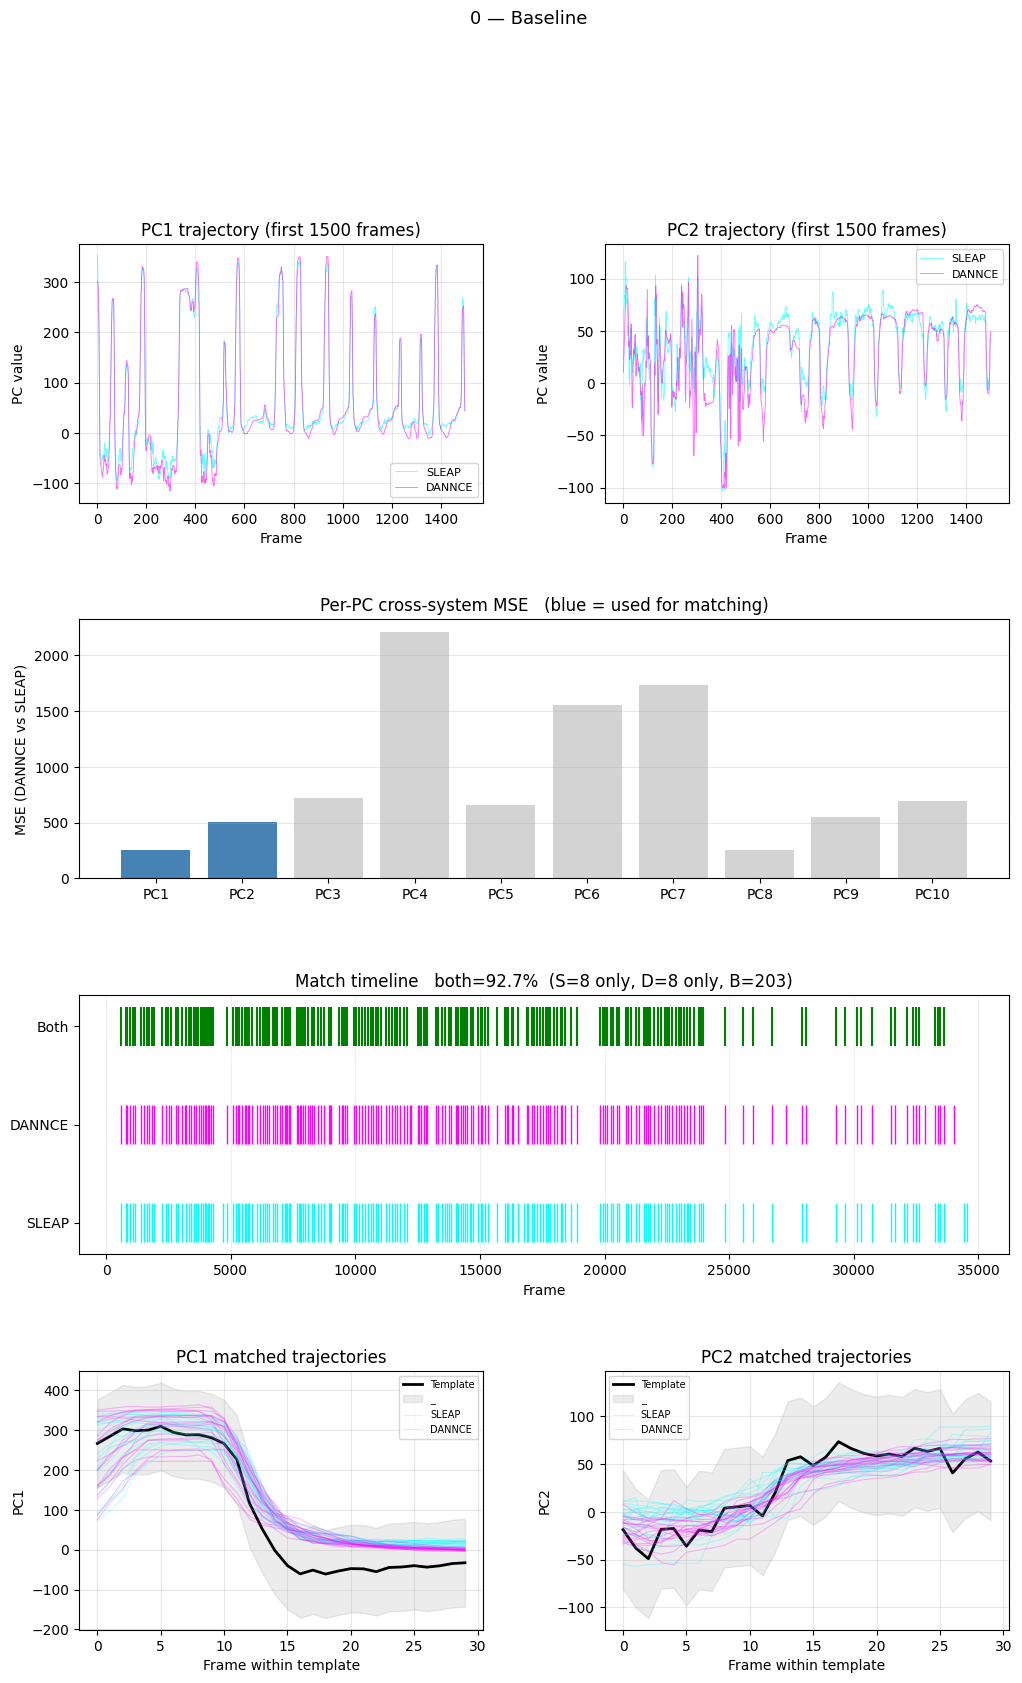

In [79]:
# ── Template (slice to n_components) ─────────────────────────────────────────
pc_template_0  = pc_template_full[:, :N_COMPONENTS]
bounds_0       = np.ones_like(pc_template_0) * bounds_scalar * feature_stds[:N_COMPONENTS]

# ── Preprocessing ─────────────────────────────────────────────────────────────
sleap_pcs_0, dannce_pcs_0, sleap_rot_0, dannce_rot_0 = standard_preprocess(
    sleap_3d_raw, dannce_3d_raw, pc_weights, feature_means)

# ── Matching ──────────────────────────────────────────────────────────────────
sm_0, dm_0 = run_matching(sleap_pcs_0, dannce_pcs_0, pc_template_0, bounds_0)

ALL_RESULTS['0_Baseline'] = comparison_report(
    '0 — Baseline', sleap_pcs_0, dannce_pcs_0, sm_0, dm_0,
    pc_template_0, bounds_0)

---
# Section 1 — DANNCE-derived template

**Rationale:** The original template trajectory was extracted from SLEAP PCs.  
Because SLEAP and DANNCE occupy slightly different regions of PC space (especially PC2+),  
a SLEAP-space template is off-centre for DANNCE.  Re-deriving the template from the DANNCE  
keypoints at the same origin frame should reduce systematic template mismatch for DANNCE.

**What changes:** Only the `pc_template` values; `pc_weights`, `feature_means`, `bounds` are unchanged.

In [41]:
temp_frame_idx


15500

In [80]:
from data_io import load_sleap_dannce_keys as _load_keys, load_aligned_data as _load_aligned

# ── Load the template origin session ─────────────────────────────────────────
temp_origin_str = str(template_data['temp_origin_file'])  # e.g. 'R1/2026_02_04_2'
temp_rat, temp_session = temp_origin_str.strip().split('/')
temp_frame_idx  = int(template_data['temp_origin_idx'])

print(f'Template origin: {temp_rat}/{temp_session}  frame {temp_frame_idx}')

# Load the origin session keypoints (raw, unfiltered) at full resolution
orig_keys    = _load_keys(temp_rat, temp_session)
orig_aligned = _load_aligned(temp_rat, temp_session)
orig_aligned_idx = orig_aligned['dannce_idx_for_sleap_cams'].astype(int).ravel()[1:]

orig_dannce  = orig_keys['dannce_keys_3D']
if orig_dannce.ndim == 4:
    orig_dannce = orig_dannce.squeeze(axis=1).transpose(0, 2, 1)
else:
    orig_dannce = np.transpose(orig_dannce, [0, 2, 1])
orig_dannce = orig_dannce[orig_aligned_idx, :, :]  # align to SLEAP timeline
orig_dannce = median_filter(orig_dannce, size=(DANNCE_MEDFILT, 1, 1))

orig_sleap = orig_keys['sleap_keys_3D']
#orig_sleap = median_filter(orig_sleap, size=(SLEAP_MEDFILT, 1, 1))

# ── Extract DANNCE template window ────────────────────────────────────────────
start_1 = temp_frame_idx + 1
if start_1 < 0:
    print(f'WARNING: template window starts before frame 0 (start={start_1}). Clamping.')
    start_1 = 0
end_1 = temp_frame_idx + template_length + 1

window = orig_dannce[start_1:end_1]          # (T, 23, 3)
if window.shape[0] < template_length:
    # Pad with first frame if needed
    pad = template_length - window.shape[0]
    window = np.concatenate([window[:1].repeat(pad, axis=0), window], axis=0)

dannce_rot_orig, _, _ = normalize_skeleton_batch(window)
flat_orig = dannce_rot_orig.reshape(template_length, -1)
dannce_template_pcs = (flat_orig - feature_means) @ pc_weights.T  # (T, n_pcs)

pc_template_1 = dannce_template_pcs[:, :N_COMPONENTS]
bounds_1      = np.ones_like(pc_template_1) * bounds_scalar * feature_stds[:N_COMPONENTS]

print(f'DANNCE template extracted: shape {pc_template_1.shape}')
print(f'Max diff vs SLEAP template: PC1={np.max(np.abs(pc_template_1[:,0] - pc_template_0[:,0])):.2f}')
if N_COMPONENTS > 1:
    print(f'                            PC2={np.max(np.abs(pc_template_1[:,1] - pc_template_0[:,1])):.2f}')

# ── Matching (use baseline SLEAP/DANNCE PCs) ──────────────────────────────────
sm_1, dm_1 = run_matching(sleap_pcs_0, dannce_pcs_0, pc_template_1, bounds_1)

ALL_RESULTS['1_DANNCE_template'] = comparison_report(
    '1 — DANNCE-derived template', sleap_pcs_0, dannce_pcs_0, sm_1, dm_1,
    pc_template_1, bounds_1)

KeyError: 'temp_origin_file'

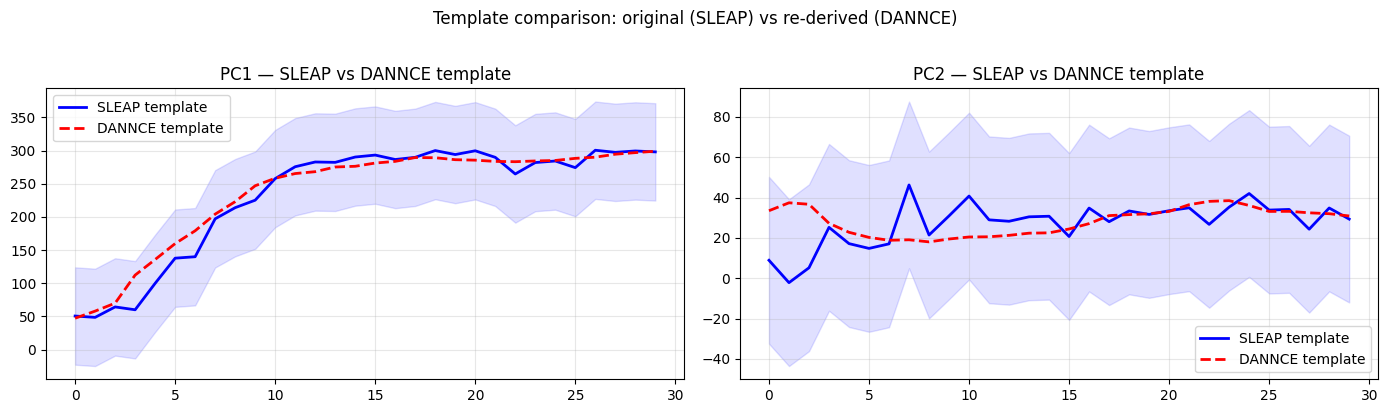

In [51]:
# Visualise SLEAP vs DANNCE template trajectories
fig, axes = plt.subplots(1, N_COMPONENTS, figsize=(7*N_COMPONENTS, 4))
if N_COMPONENTS == 1: axes = [axes]
t_ax = np.arange(template_length)
for pc in range(N_COMPONENTS):
    axes[pc].plot(t_ax, pc_template_full[:, pc], 'b-',  lw=2, label='SLEAP template')
    axes[pc].plot(t_ax, dannce_template_pcs[:, pc], 'r--', lw=2, label='DANNCE template')
    axes[pc].fill_between(t_ax,
                           pc_template_full[:, pc] - bounds_scalar * feature_stds[pc],
                           pc_template_full[:, pc] + bounds_scalar * feature_stds[pc],
                           alpha=0.12, color='blue')
    axes[pc].set_title(f'PC{pc+1} — SLEAP vs DANNCE template')
    axes[pc].legend(); axes[pc].grid(alpha=0.3)
plt.suptitle('Template comparison: original (SLEAP) vs re-derived (DANNCE)', y=1.02)
plt.tight_layout(); plt.show()

---
# Section 2 — PC-scaled bounds (widen bounds on higher PCs)

**Rationale:** The current bounds treat all PCs identically: `bound_k = scalar × std_k`.  
But PC2 has ~2× the cross-system MSE of PC1, meaning the current bound is too tight for PC2  
relative to the noise level introduced by SLEAP-DANNCE discrepancy.  

**What changes:** The bounds for each PC are widened by adding the empirically measured  
cross-system PC error in quadrature: `bound_k = scalar × sqrt(std_k² + α × cross_err_k)`.  
The α parameter controls how aggressively bounds are widened (0 = baseline, 1 = full correction).

Per-PC cross-system RMSE (used for bound widening):
  PC1: RMSE=17.51  baseline_bound=73.34
  PC2: RMSE=24.58  baseline_bound=41.36

α=0.5  new bounds:
  PC1: 73.34 → 74.37  (+1.4%)
  PC2: 41.36 → 44.87  (+8.5%)

  2 — PC-scaled bounds (α=0.5)
  SLEAP matches :   33  |  DANNCE matches :   28
  Both          :   21  |  SLEAP-only     :   12  |  DANNCE-only :    7
  Alignment     :  52.5%  (21/40)
  PC MSE        : PC1=306.6  PC2=604.2


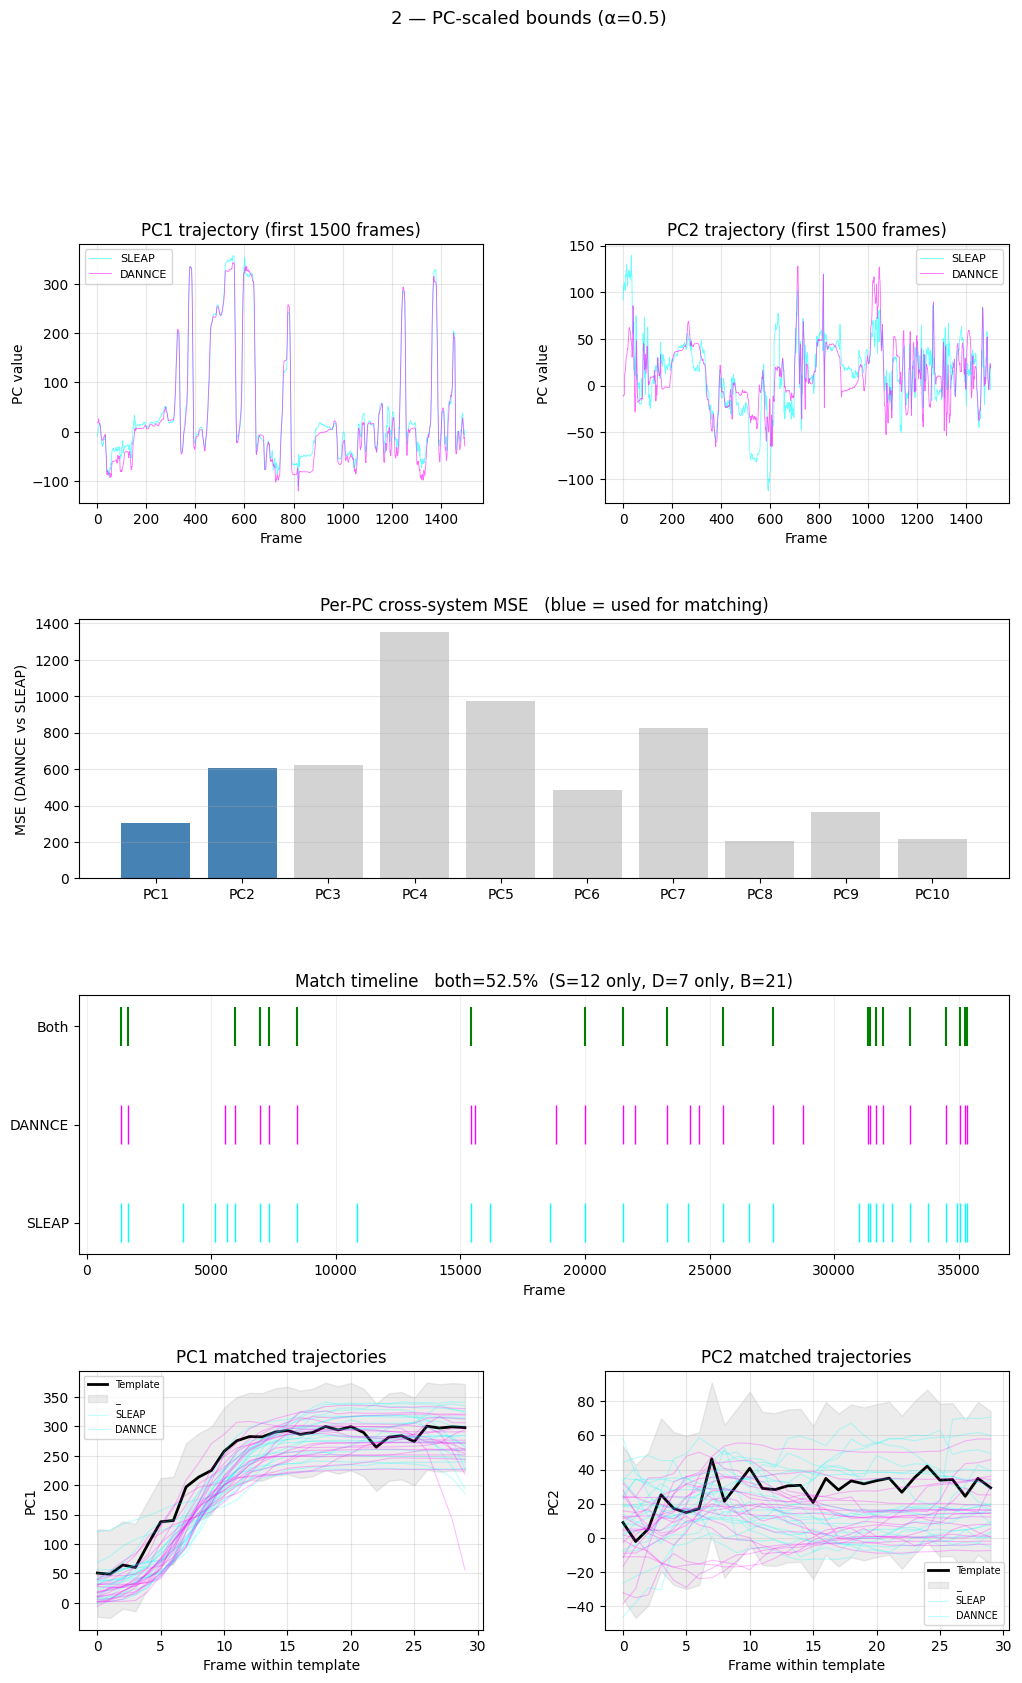

In [52]:
# ── Compute cross-system error per PC from this session ───────────────────────
per_pc_mse = np.mean((dannce_pcs_0 - sleap_pcs_0)**2, axis=0)   # (n_pcs,)
per_pc_rmse = np.sqrt(per_pc_mse)

print('Per-PC cross-system RMSE (used for bound widening):')
for i, v in enumerate(per_pc_rmse[:N_COMPONENTS]):
    print(f'  PC{i+1}: RMSE={v:.2f}  baseline_bound={bounds_scalar * feature_stds[i]:.2f}')

# ── Tune α  (0 = unchanged, 1 = full quad addition, try values in 0.2..1.0) ───
ALPHA_BOUND = 0.5   # <── adjust this

# Effective bound: sqrt(original_bound² + α * cross_err²)
orig_bound_vals = bounds_scalar * feature_stds[:N_COMPONENTS]       # (n_comp,)
new_bound_vals  = np.sqrt(orig_bound_vals**2 + ALPHA_BOUND * per_pc_mse[:N_COMPONENTS])

print(f'\nα={ALPHA_BOUND}  new bounds:')
for i in range(N_COMPONENTS):
    print(f'  PC{i+1}: {orig_bound_vals[i]:.2f} → {new_bound_vals[i]:.2f}'
          f'  (+{100*(new_bound_vals[i]/orig_bound_vals[i]-1):.1f}%)')

pc_template_2 = pc_template_full[:, :N_COMPONENTS]
bounds_2      = np.ones_like(pc_template_2) * new_bound_vals[np.newaxis, :]

sm_2, dm_2 = run_matching(sleap_pcs_0, dannce_pcs_0, pc_template_2, bounds_2)

ALL_RESULTS['2_PC_scaled_bounds'] = comparison_report(
    f'2 — PC-scaled bounds (α={ALPHA_BOUND})', sleap_pcs_0, dannce_pcs_0, sm_2, dm_2,
    pc_template_2, bounds_2)

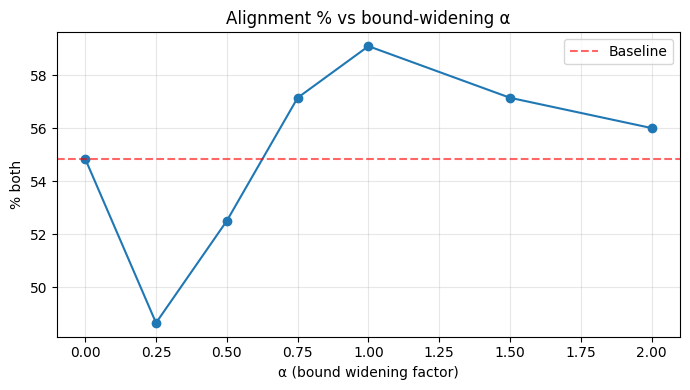

In [53]:
# ── Sweep α to see sensitivity ────────────────────────────────────────────────
alphas = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pct_both_by_alpha = []
for a in alphas:
    bv  = np.sqrt(orig_bound_vals**2 + a * per_pc_mse[:N_COMPONENTS])
    b   = np.ones((template_length, N_COMPONENTS)) * bv[np.newaxis, :]
    sm_, dm_ = run_matching(sleap_pcs_0, dannce_pcs_0, pc_template_full, b)
    so_, do_, bo_ = get_match_overlap(dm_, sm_)
    n_ = len(so_) + len(do_) + len(bo_)
    pct_both_by_alpha.append(100.0 * len(bo_) / n_ if n_ > 0 else 0.0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, pct_both_by_alpha, 'o-')
ax.axhline(ALL_RESULTS['0_Baseline']['pct_both'], color='red', ls='--', alpha=0.6, label='Baseline')
ax.set_xlabel('α (bound widening factor)'); ax.set_ylabel('% both')
ax.set_title('Alignment % vs bound-widening α'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# Section 3 — Joint feature means (pooled SLEAP + DANNCE)

**Rationale:** The PCA `feature_means` was fit on SLEAP training data only.  
DANNCE occupies a slightly different mean position in feature space (~7 units mean absolute diff  
across features, from notebook cell 11). Recentering the PCA projection on the pooled mean  
should make both systems project more symmetrically into PC space.

**What changes:** `feature_means` is replaced by the average of the per-session SLEAP and DANNCE means.  
`pc_weights` (eigenvectors) stay the same — only the origin shifts.

Max feature mean shift: 35.712  (mean: 5.124)

  3 — Joint feature means
  SLEAP matches :   31  |  DANNCE matches :   27
  Both          :   20  |  SLEAP-only     :   11  |  DANNCE-only :    7
  Alignment     :  52.6%  (20/38)
  PC MSE        : PC1=306.6  PC2=604.2


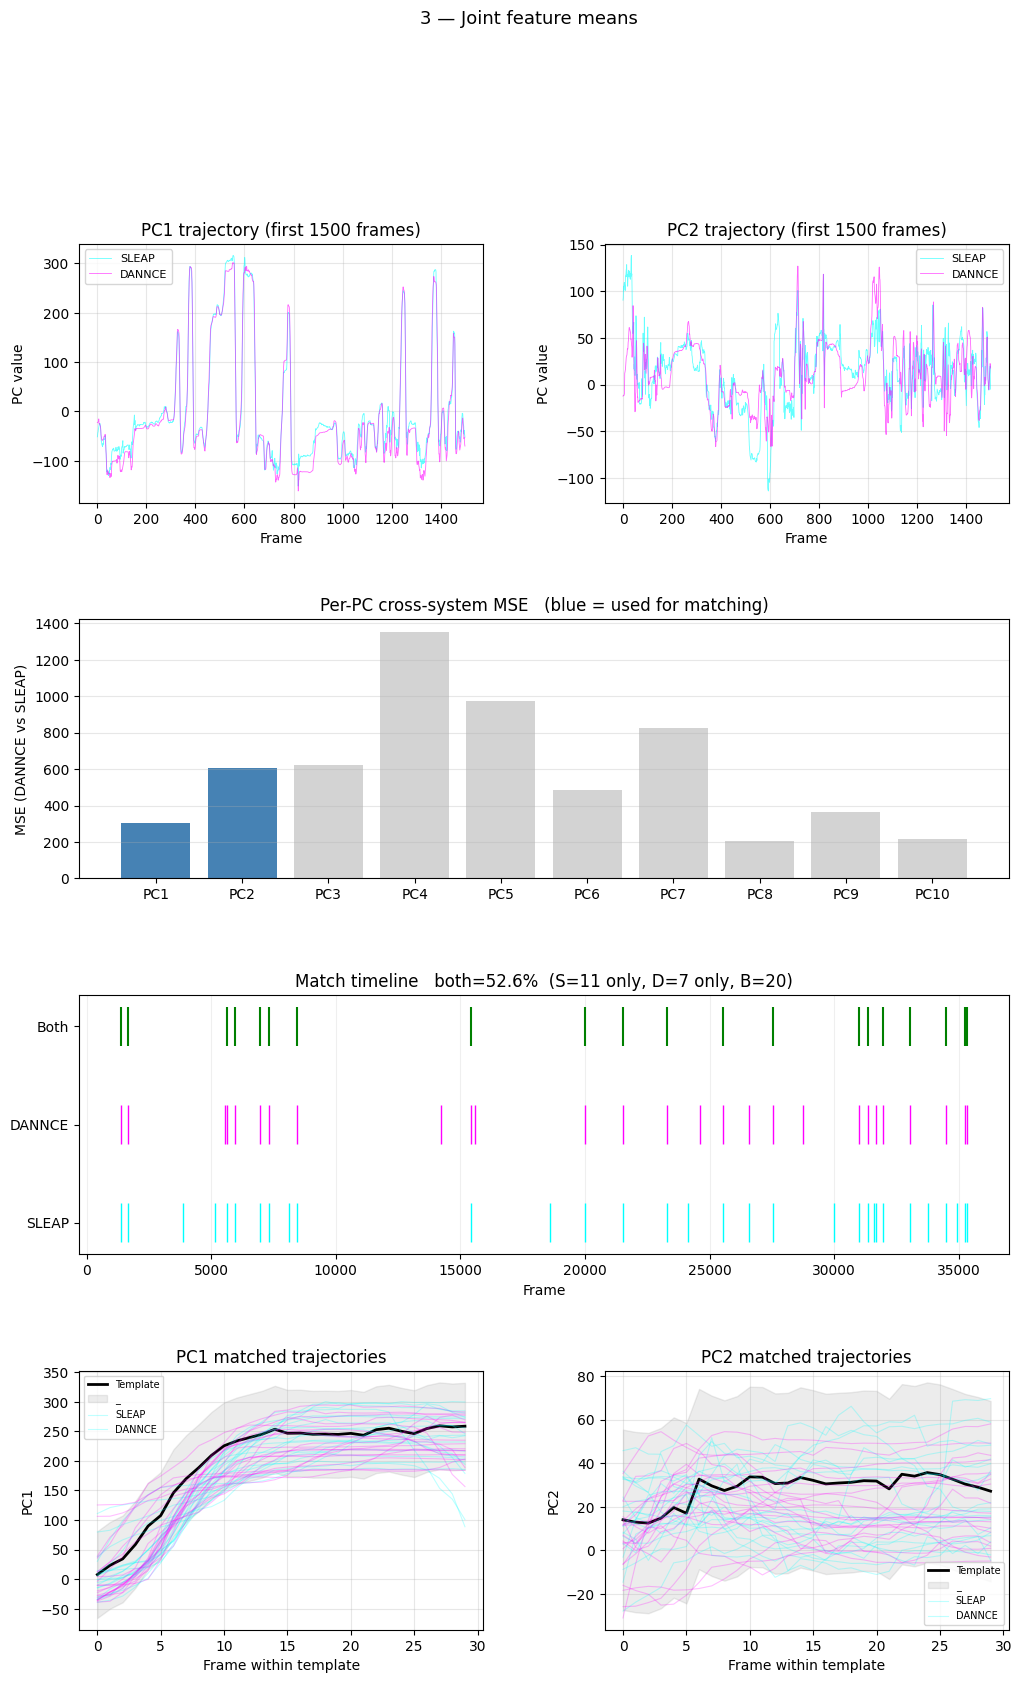

In [54]:
# ── Compute pooled feature mean from this session ─────────────────────────────
sleap_fl_3  = sleap_3d_raw.copy(); sleap_fl_3[:, :, 2] = -sleap_fl_3[:, :, 2]
sleap_rot_3, _, _ = normalize_skeleton_batch(sleap_fl_3)
dannce_rot_3, _, _ = normalize_skeleton_batch(dannce_3d_raw)

flat_sleap_3  = sleap_rot_3.reshape(sleap_rot_3.shape[0],  -1)
flat_dannce_3 = dannce_rot_3.reshape(dannce_rot_3.shape[0], -1)

# Pooled mean: average of SLEAP and DANNCE session means
feature_means_joint = (flat_sleap_3.mean(axis=0) + flat_dannce_3.mean(axis=0)) / 2.0

mean_diff = np.abs(feature_means_joint - feature_means)
print(f'Max feature mean shift: {mean_diff.max():.3f}  (mean: {mean_diff.mean():.3f})')

# ── Re-project with new feature means ─────────────────────────────────────────
sleap_pcs_3  = (flat_sleap_3  - feature_means_joint) @ pc_weights.T
dannce_pcs_3 = (flat_dannce_3 - feature_means_joint) @ pc_weights.T

# Re-derive template in new PC space (from SLEAP origin — same as baseline)
# (re-project the template origin window with the new mean)
orig_sleap   = load_sleap_dannce_keys(temp_rat, temp_session)['sleap_keys_3D']
orig_sleap   = median_filter(orig_sleap, size=(SLEAP_MEDFILT, 1, 1))
start_3 = temp_frame_idx + 1
end_3   = temp_frame_idx + template_length + 1
win_sl = orig_sleap[start_3:end_3].copy()
win_sl[:, :, 2] = -win_sl[:, :, 2]
if len(win_sl) < template_length:
    win_sl = np.concatenate([win_sl, win_sl[-1:].repeat(template_length - len(win_sl), axis=0)])
win_sl_rot, _, _ = normalize_skeleton_batch(win_sl)
flat_win = win_sl_rot.reshape(template_length, -1)
pc_template_3 = ((flat_win - feature_means_joint) @ pc_weights.T)[:, :N_COMPONENTS]

bounds_3 = np.ones_like(pc_template_3) * bounds_scalar * feature_stds[:N_COMPONENTS]

sm_3, dm_3 = run_matching(sleap_pcs_3, dannce_pcs_3, pc_template_3, bounds_3)

ALL_RESULTS['3_Joint_means'] = comparison_report(
    '3 — Joint feature means', sleap_pcs_3, dannce_pcs_3, sm_3, dm_3,
    pc_template_3, bounds_3)

---
# Section 4 — Procrustes alignment (SLEAP → DANNCE coordinate frame)

**Rationale:** SLEAP triangulation and DANNCE produce 3D keypoints in slightly different coordinate  
systems (scale, rotation, translation). `qc_utils.find_sleap_dannce_alignment` fits an optimal  
rotation+scale+translation to map SLEAP into DANNCE space. Applying this transform before  
normalization and PCA projection should directly reduce the upstream feature-space discrepancy.

**Runtime:** The transform is a fixed (3×3 R, scalar s, 3-vector t) — applying it to one frame  
is a single matrix multiply, <0.1 ms.

**What changes:** SLEAP 3D keypoints are pre-transformed before Z-flip, normalization, and projection.

Procrustes residual: 218.456
Scale: 0.0429  z_flipped: False

  4 — Procrustes alignment
  SLEAP matches :    0  |  DANNCE matches :   22
  Both          :    0  |  SLEAP-only     :    0  |  DANNCE-only :   22
  Alignment     :   0.0%  (0/22)
  PC MSE        : PC1=14527.9  PC2=1439.5


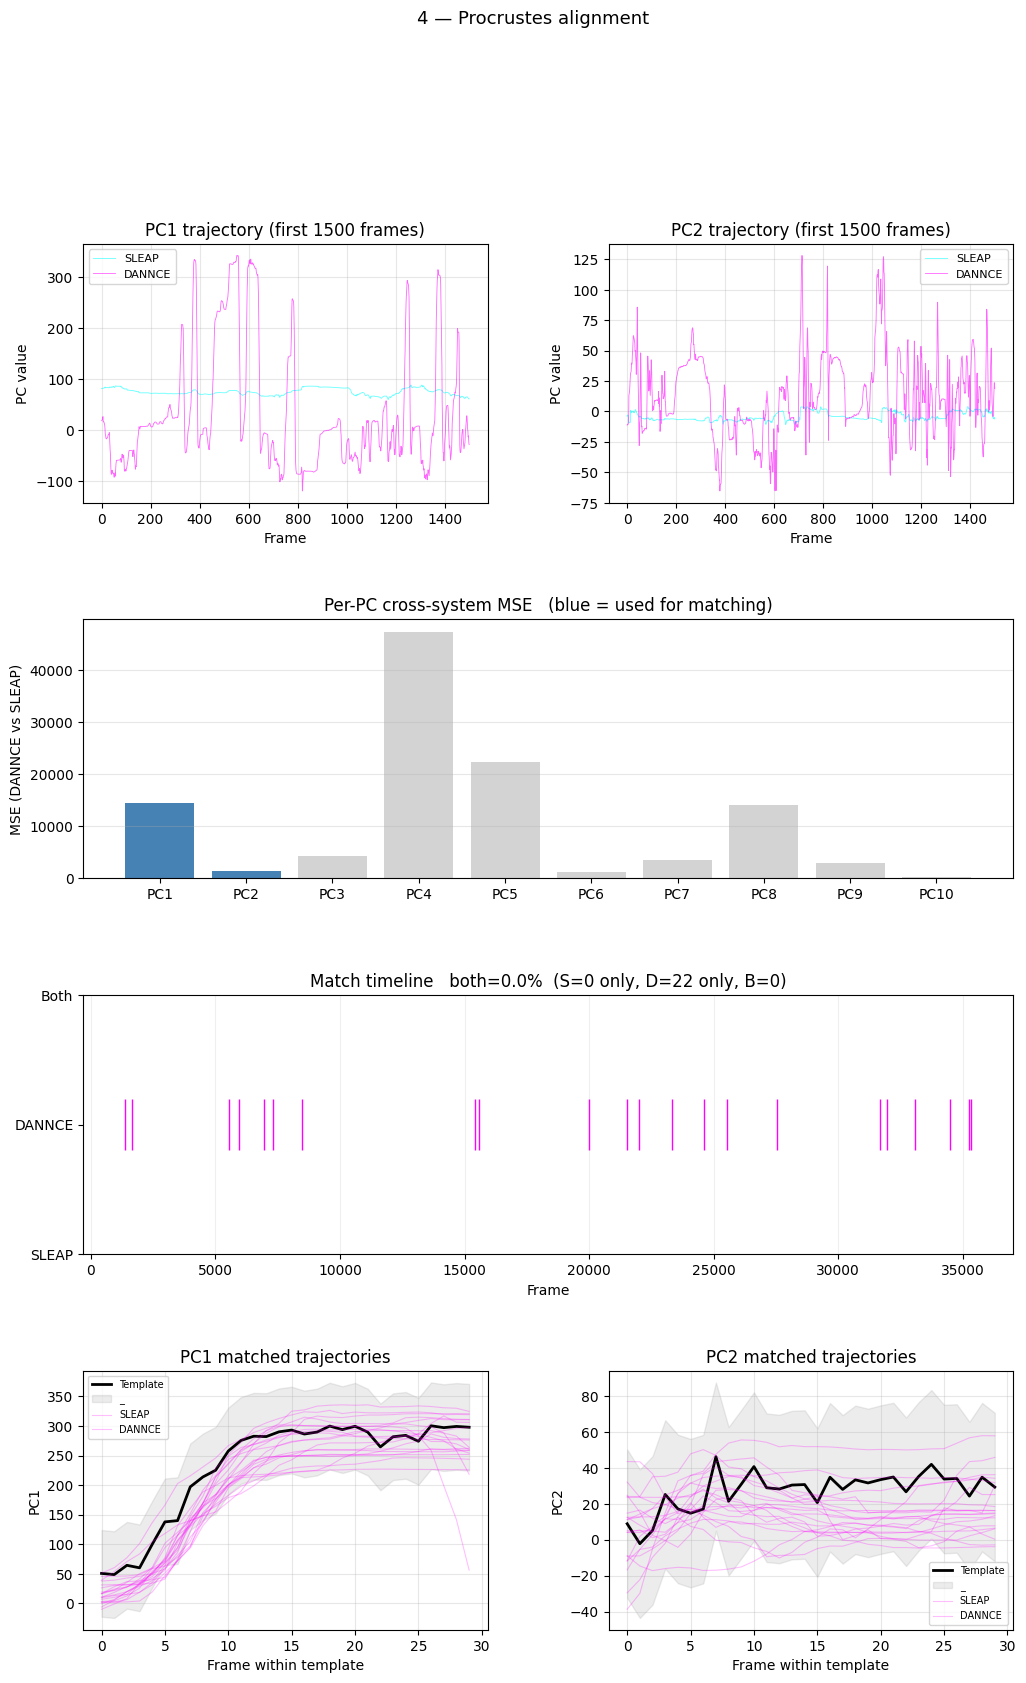

In [55]:
# ── Fit Procrustes transform on this session ───────────────────────────────────
# Use unfiltered SLEAP (with Z flip) and unfiltered DANNCE
sleap_for_align = sleap_3d_raw.copy()
sleap_for_align[:, :, 2] = -sleap_for_align[:, :, 2]   # Z flip before alignment

alignment = find_sleap_dannce_alignment(
    sleap_for_align, dannce_3d_raw, aligned_indices,
    n_sample_frames=500, seed=42, try_z_flip=False)  # z_flip already applied

print(f'Procrustes residual: {alignment["residual"]:.3f}')
print(f'Scale: {alignment["s"]:.4f}  z_flipped: {alignment["z_flipped"]}')

# ── Apply transform to SLEAP keypoints ────────────────────────────────────────
sleap_aligned_4 = alignment['apply'](sleap_for_align)  # (..., 23, 3) already z-flipped

# Normalise and project — note: no Z-flip here since flip was applied above
sleap_rot_4, _, _ = normalize_skeleton_batch(sleap_aligned_4)
sleap_pcs_4  = project_to_pcs(sleap_rot_4,  pc_weights, feature_means)

dannce_rot_4, _, _ = normalize_skeleton_batch(dannce_3d_raw)
dannce_pcs_4 = project_to_pcs(dannce_rot_4, pc_weights, feature_means)

pc_template_4 = pc_template_full[:, :N_COMPONENTS]
bounds_4      = np.ones_like(pc_template_4) * bounds_scalar * feature_stds[:N_COMPONENTS]

sm_4, dm_4 = run_matching(sleap_pcs_4, dannce_pcs_4, pc_template_4, bounds_4)

ALL_RESULTS['4_Procrustes'] = comparison_report(
    '4 — Procrustes alignment', sleap_pcs_4, dannce_pcs_4, sm_4, dm_4,
    pc_template_4, bounds_4)

---
# Section 5 — Pairwise distance features

**Rationale:** The current 69D feature vector contains absolute (x, y, z) keypoint positions after  
egocentric normalization. Residual biases between SLEAP and DANNCE (especially in Z) feed directly  
into these features and cause PC2+ divergence.  
Pairwise inter-keypoint distances are translation-, rotation-, and Z-scale-invariant — making them  
intrinsically robust to coordinate-system differences between the two systems.

**What changes:** Feature extraction: (23,3) → 253 upper-triangle pairwise distances → PCA.  
The PC axes change, so a new template must be extracted in this new space.

**Note:** PCA weights (`pc_weights`) from the template file are incompatible — we fit a fresh PCA  
on the pooled distance features from this session. For production use, PCA should be re-fit on a  
larger training set (freely-moving data) in the same way `pc_weights` was originally created.

In [56]:
# ── Pairwise distance feature extraction ─────────────────────────────────────
def pairwise_distances(keys_3d):
    """Compute upper-triangle pairwise distances.
    keys_3d : (n_frames, 23, 3)  ->  returns (n_frames, 253)
    """
    n = keys_3d.shape[0]
    k = N_KEYPOINTS
    n_pairs = k * (k - 1) // 2
    out = np.empty((n, n_pairs), dtype=np.float32)
    idx = 0
    for i in range(k):
        for j in range(i + 1, k):
            out[:, idx] = np.linalg.norm(keys_3d[:, i, :] - keys_3d[:, j, :], axis=1)
            idx += 1
    return out.astype(float)


def fit_pca_on_features(feat_matrix, n_components):
    """Fit PCA: returns (weights (n_comp, n_feat), means (n_feat,), stds (n_comp,))."""
    means = feat_matrix.mean(axis=0)
    centred = feat_matrix - means
    U, S, Vt = np.linalg.svd(centred, full_matrices=False)
    weights = Vt[:n_components]            # (n_comp, n_feat)
    projected = centred @ weights.T        # (n_frames, n_comp)
    stds = projected.std(axis=0)           # (n_comp,)
    return weights, means, stds, projected

Pairwise feature PCA: 253 features → 10 PCs
Per-PC MSE (pairwise dist): PC1=3649.5  PC2=1515.7
Per-PC MSE (baseline):     PC1=306.6  PC2=604.2

  5 — Pairwise distance features
  SLEAP matches :   45  |  DANNCE matches :   50
  Both          :   34  |  SLEAP-only     :   11  |  DANNCE-only :   16
  Alignment     :  55.7%  (34/61)
  PC MSE        : PC1=3649.5  PC2=1515.7


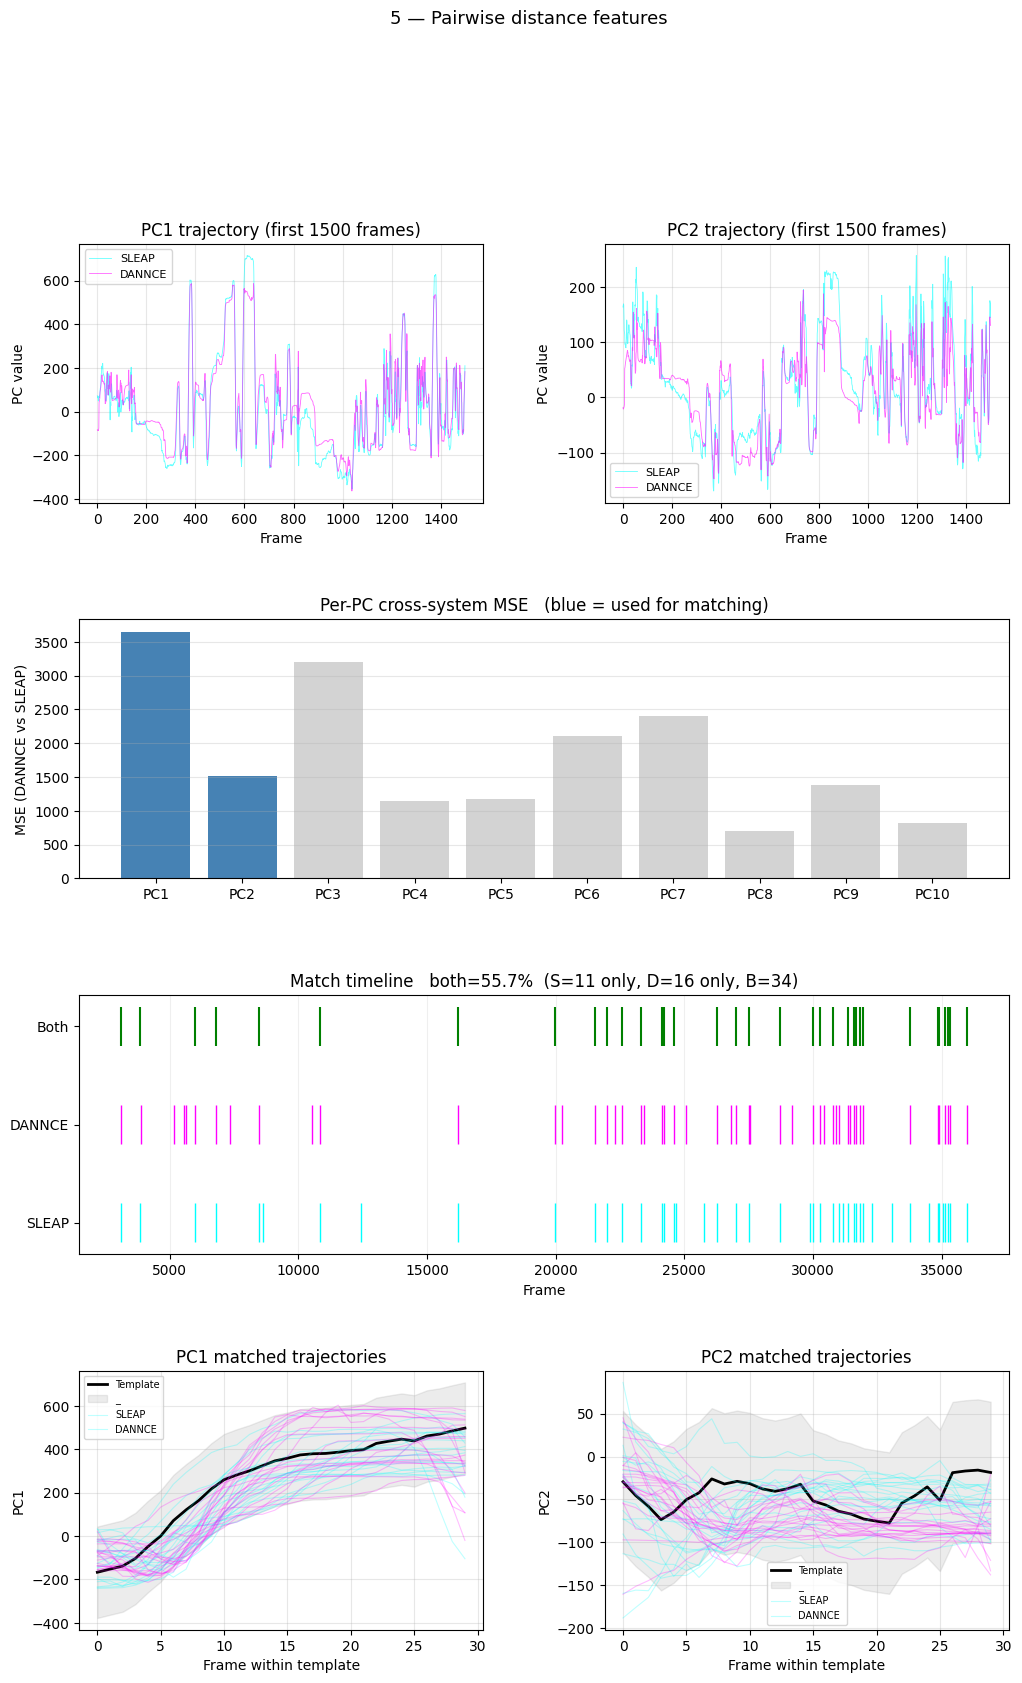

In [57]:
N_PCA_DIST = 10   # number of PCA components to keep from pairwise distance features

# ── Normalize both (no PCA projection yet) ────────────────────────────────────
# For pairwise distances we can skip egocentric normalisation (distances are
# rotation/translation invariant), but we still apply it so that the PCA space
# is comparable to the original when combining approaches later.
sleap_fl_5 = sleap_3d_raw.copy(); sleap_fl_5[:, :, 2] = -sleap_fl_5[:, :, 2]
sleap_rot_5,  _, _ = normalize_skeleton_batch(sleap_fl_5)
dannce_rot_5, _, _ = normalize_skeleton_batch(dannce_3d_raw)

# ── Compute pairwise distance features ────────────────────────────────────────
feat_sleap_5  = pairwise_distances(sleap_rot_5)   # (n, 253)
feat_dannce_5 = pairwise_distances(dannce_rot_5)

# ── Fit PCA on pooled features ─────────────────────────────────────────────────
feat_pooled_5 = np.concatenate([feat_sleap_5, feat_dannce_5], axis=0)
pw_weights, pw_means, pw_stds, _ = fit_pca_on_features(feat_pooled_5, N_PCA_DIST)

sleap_pcs_5  = (feat_sleap_5  - pw_means) @ pw_weights.T
dannce_pcs_5 = (feat_dannce_5 - pw_means) @ pw_weights.T

print(f'Pairwise feature PCA: {feat_pooled_5.shape[1]} features → {N_PCA_DIST} PCs')
pc_mse_5 = np.mean((dannce_pcs_5 - sleap_pcs_5)**2, axis=0)
print('Per-PC MSE (pairwise dist):',  '  '.join([f'PC{i+1}={v:.1f}' for i, v in enumerate(pc_mse_5[:N_COMPONENTS])]))
print('Per-PC MSE (baseline):    ',   '  '.join([f'PC{i+1}={v:.1f}' for i, v in enumerate(ALL_RESULTS['0_Baseline']['pc_mse'][:N_COMPONENTS])]))

# ── Extract template in pairwise-distance PC space ────────────────────────────
orig_sleap_5 = load_sleap_dannce_keys(temp_rat, temp_session)['sleap_keys_3D']
orig_sleap_5 = median_filter(orig_sleap_5, size=(SLEAP_MEDFILT, 1, 1))
start_5 = temp_frame_idx + 1
end_5   = temp_frame_idx + template_length + 1
win_5 = orig_sleap_5[start_5:end_5].copy()
win_5[:, :, 2] = -win_5[:, :, 2]
if len(win_5) < template_length:
    win_5 = np.concatenate([win_5, win_5[-1:].repeat(template_length - len(win_5), axis=0)])
win_5_rot, _, _ = normalize_skeleton_batch(win_5)
feat_win_5 = pairwise_distances(win_5_rot)
template_pcs_5 = ((feat_win_5 - pw_means) @ pw_weights.T)[:, :N_COMPONENTS]

bounds_5 = np.ones_like(template_pcs_5) * bounds_scalar * pw_stds[:N_COMPONENTS]

sm_5, dm_5 = run_matching(sleap_pcs_5, dannce_pcs_5, template_pcs_5, bounds_5)

ALL_RESULTS['5_Pairwise_dist'] = comparison_report(
    '5 — Pairwise distance features', sleap_pcs_5, dannce_pcs_5, sm_5, dm_5,
    template_pcs_5, bounds_5)

---
# Section 6 — Calibrated bounds from cross-system error

**Rationale:** Directly use the empirically observed SLEAP–DANNCE PC error distribution  
to set bounds. For each PC and each template time point, the bound is set to:  
`max(original_bound, cross_system_99th_percentile)`  
This guarantees that if SLEAP and DANNCE agree with each other at the population level,  
both should fall within bounds.  

**What changes:** Per-timepoint bounds derived from the error distribution, not just the std.

Cross-system 95% error per PC:
  PC1: 34.46  (baseline bound: 73.34)
  PC2: 51.30  (baseline bound: 41.36)

Final calibrated bounds: [73.33700419 51.29980698]

  6 — Calibrated bounds (q=95%)
  SLEAP matches :   37  |  DANNCE matches :   35
  Both          :   24  |  SLEAP-only     :   13  |  DANNCE-only :   11
  Alignment     :  50.0%  (24/48)
  PC MSE        : PC1=306.6  PC2=604.2


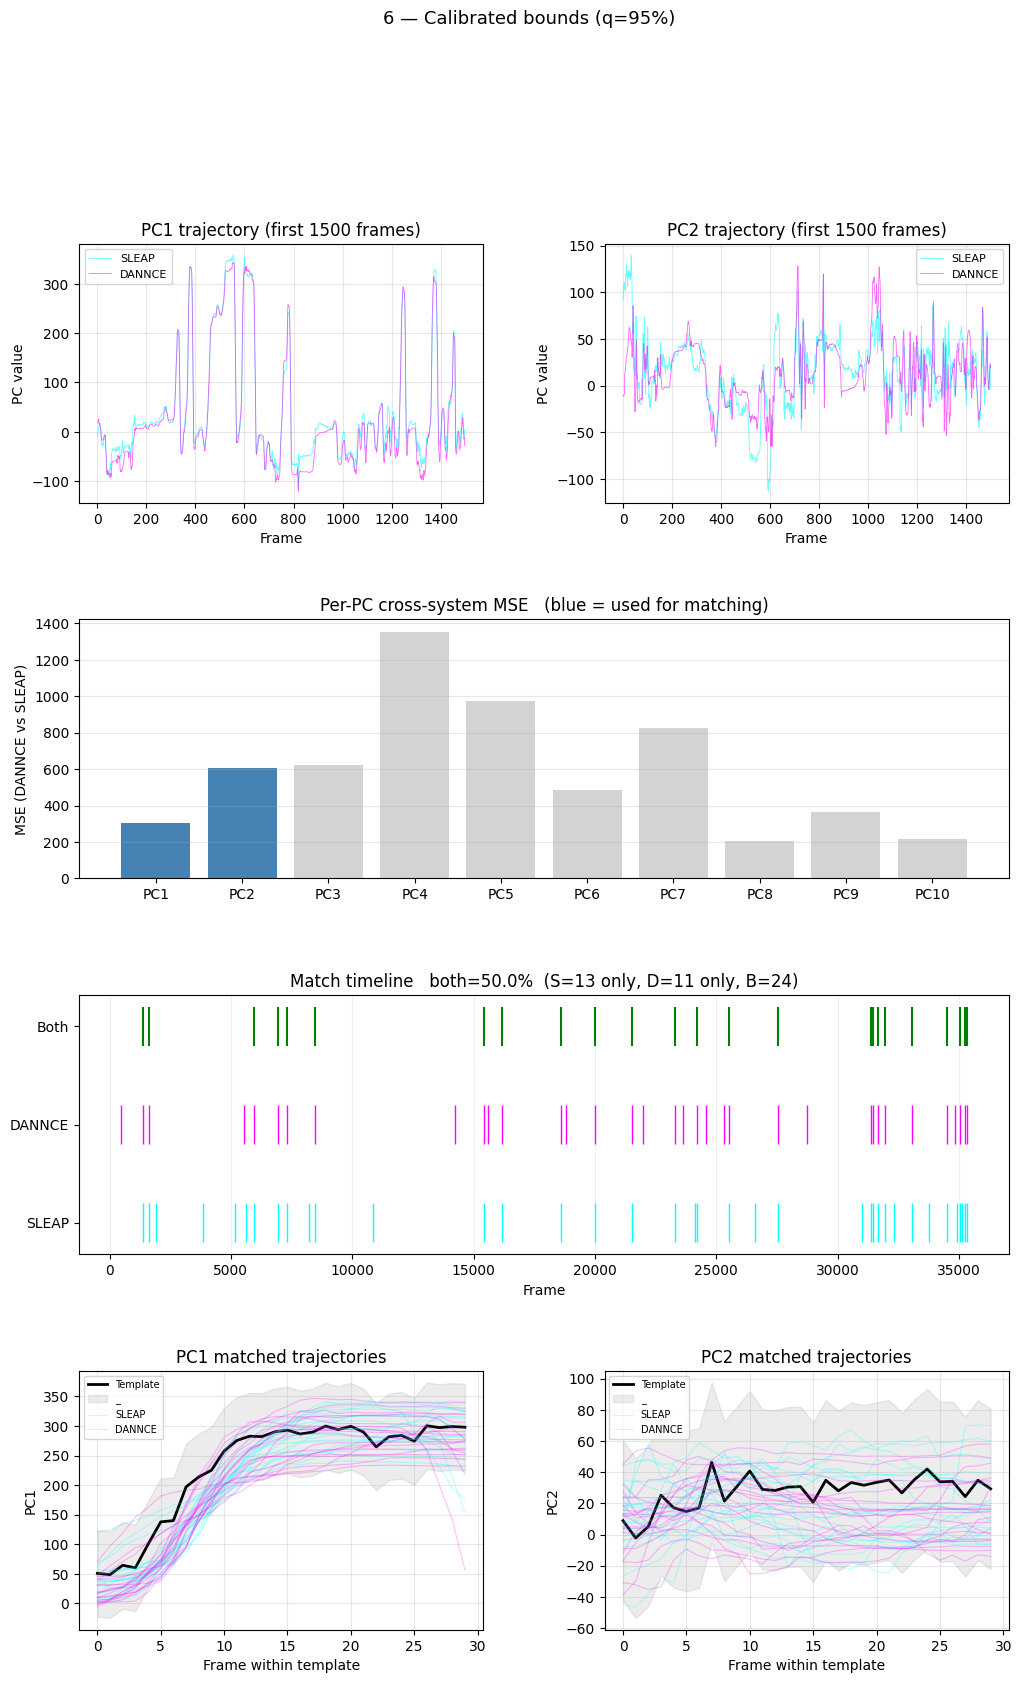

In [58]:
# ── Compute per-PC error quantiles ────────────────────────────────────────────
pc_err_abs = np.abs(dannce_pcs_0[:, :N_COMPONENTS] - sleap_pcs_0[:, :N_COMPONENTS])  # (n,k)

QUANTILE = 0.95   # <── adjust: 0.90, 0.95, 0.99
per_pc_q = np.quantile(pc_err_abs, QUANTILE, axis=0)   # (n_comp,)

print(f'Cross-system {QUANTILE:.0%} error per PC:')
for i in range(N_COMPONENTS):
    print(f'  PC{i+1}: {per_pc_q[i]:.2f}  (baseline bound: {bounds_scalar * feature_stds[i]:.2f})')

# Bounds: take the max of the original and the calibrated quantile
cal_bound_vals = np.maximum(bounds_scalar * feature_stds[:N_COMPONENTS], per_pc_q)
print('\nFinal calibrated bounds:', cal_bound_vals)

pc_template_6 = pc_template_full[:, :N_COMPONENTS]
bounds_6      = np.ones((template_length, N_COMPONENTS)) * cal_bound_vals[np.newaxis, :]

sm_6, dm_6 = run_matching(sleap_pcs_0, dannce_pcs_0, pc_template_6, bounds_6)

ALL_RESULTS['6_Calibrated_bounds'] = comparison_report(
    f'6 — Calibrated bounds (q={QUANTILE:.0%})', sleap_pcs_0, dannce_pcs_0, sm_6, dm_6,
    pc_template_6, bounds_6)

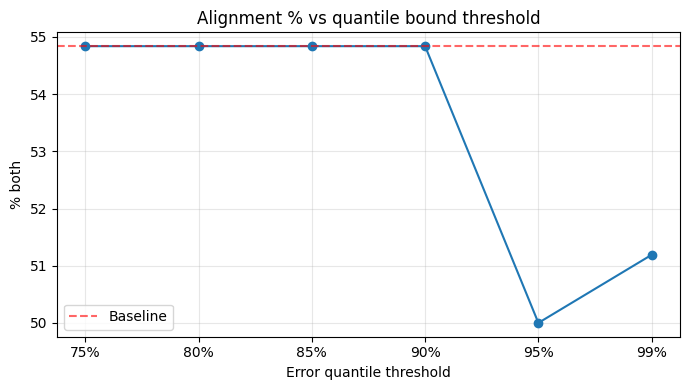

In [59]:
# ── Sweep quantile threshold ────────────────────────────────────────────────────
quantiles = [0.75, 0.80, 0.85, 0.90, 0.95, 0.99]
pct_both_by_q = []
for q in quantiles:
    pq  = np.quantile(pc_err_abs, q, axis=0)
    cbv = np.maximum(bounds_scalar * feature_stds[:N_COMPONENTS], pq)
    b   = np.ones((template_length, N_COMPONENTS)) * cbv[np.newaxis, :]
    sm_, dm_ = run_matching(sleap_pcs_0, dannce_pcs_0, pc_template_full, b)
    so_, do_, bo_ = get_match_overlap(dm_, sm_)
    n_ = len(so_) + len(do_) + len(bo_)
    pct_both_by_q.append(100.0 * len(bo_) / n_ if n_ > 0 else 0.0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([f'{q:.0%}' for q in quantiles], pct_both_by_q, 'o-')
ax.axhline(ALL_RESULTS['0_Baseline']['pct_both'], color='red', ls='--', alpha=0.6, label='Baseline')
ax.set_xlabel('Error quantile threshold'); ax.set_ylabel('% both')
ax.set_title('Alignment % vs quantile bound threshold'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# Section 7 — Session-specific PC offset correction (offline only)

**Rationale:** Even after normalization, SLEAP and DANNCE may have systematic mean offsets in  
PC space that vary by session (camera calibration, animal, etc.).  
If a freely-moving segment is available, a session-specific mean offset can be estimated and removed.  
This is the strongest single-session correction but requires the DANNCE data, so it cannot be used online.

**What changes:** A per-PC mean shift is subtracted from SLEAP PCs before matching.  
The template is left unchanged (it lives in DANNCE-aligned space after correction).

Per-PC mean offset (SLEAP - DANNCE):
  PC1: +8.932
  PC2: -0.060
Per-PC std ratio (DANNCE/SLEAP): PC1=1.046  PC2=1.009

  7 — Session PC offset correction
  SLEAP matches :   26  |  DANNCE matches :   21
  Both          :   16  |  SLEAP-only     :   10  |  DANNCE-only :    5
  Alignment     :  51.6%  (16/31)
  PC MSE        : PC1=212.9  PC2=609.4


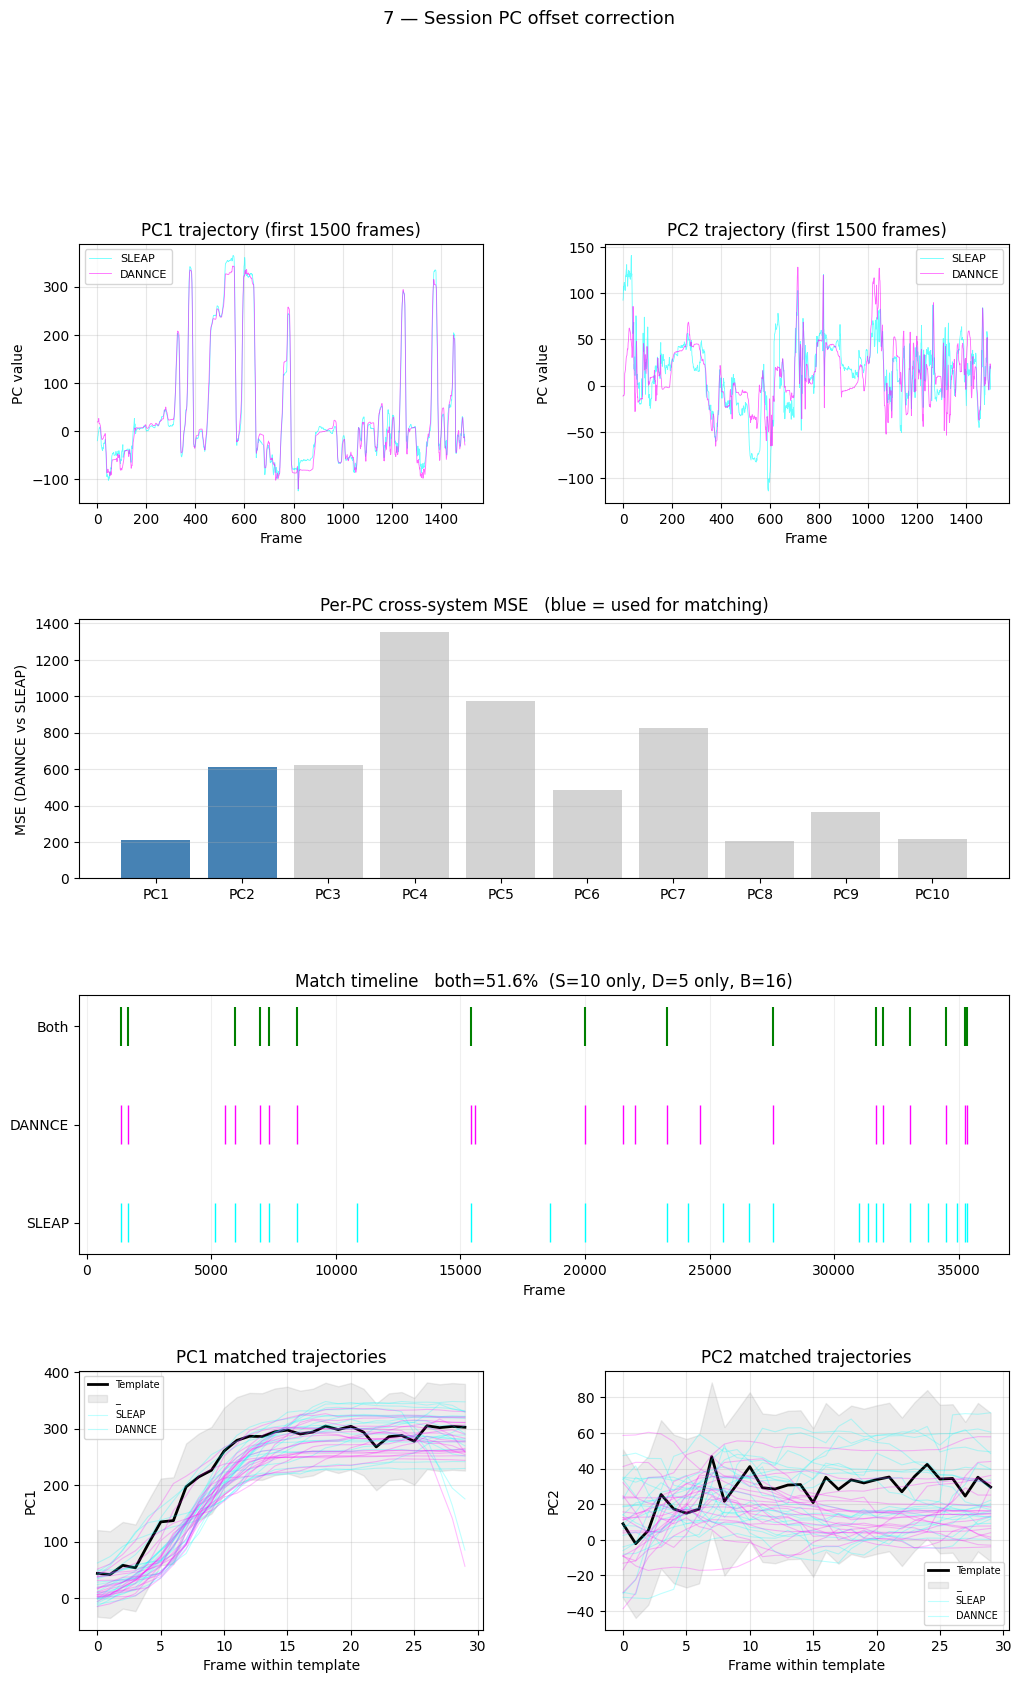

In [60]:
# ── Estimate per-PC mean offset from the whole session ────────────────────────
# (In practice you would restrict this to a pre-task freely-moving epoch;
#  here we use the full session as a proxy.)

# Mean PC values for each system
sleap_pc_mean_7  = sleap_pcs_0[:, :N_COMPONENTS].mean(axis=0)
dannce_pc_mean_7 = dannce_pcs_0[:, :N_COMPONENTS].mean(axis=0)
offset_7 = sleap_pc_mean_7 - dannce_pc_mean_7   # what to subtract from SLEAP

print('Per-PC mean offset (SLEAP - DANNCE):')
for i, v in enumerate(offset_7):
    print(f'  PC{i+1}: {v:+.3f}')

# Also estimate a per-PC scale correction
sleap_pc_std_7  = sleap_pcs_0[:, :N_COMPONENTS].std(axis=0)
dannce_pc_std_7 = dannce_pcs_0[:, :N_COMPONENTS].std(axis=0)
scale_7 = dannce_pc_std_7 / (sleap_pc_std_7 + 1e-8)
print('Per-PC std ratio (DANNCE/SLEAP):', '  '.join([f'PC{i+1}={v:.3f}' for i, v in enumerate(scale_7)]))

# Apply offset (and optionally scale) correction to SLEAP PCs
sleap_pcs_7 = (sleap_pcs_0[:, :N_COMPONENTS] - offset_7) * scale_7
# Pad remaining PCs unchanged for MSE comparison
sleap_pcs_7_full = sleap_pcs_0.copy()
sleap_pcs_7_full[:, :N_COMPONENTS] = sleap_pcs_7

# Template does not need to change — it is in DANNCE PC space already after offset removal
pc_template_7 = pc_template_full[:, :N_COMPONENTS]
# But the template also needs to be scaled to the corrected space:
template_centred = pc_template_7 - sleap_pc_mean_7[np.newaxis, :]
pc_template_7_corr = (template_centred + dannce_pc_mean_7[np.newaxis, :]) * scale_7[np.newaxis, :]

bounds_7 = np.ones_like(pc_template_7_corr) * bounds_scalar * (feature_stds[:N_COMPONENTS] * scale_7)

sm_7, dm_7 = run_matching(sleap_pcs_7_full, dannce_pcs_0, pc_template_7_corr, bounds_7)

ALL_RESULTS['7_PC_offset'] = comparison_report(
    '7 — Session PC offset correction', sleap_pcs_7_full, dannce_pcs_0, sm_7, dm_7,
    pc_template_7_corr, bounds_7)

---
# Section 8 — Keypoint subsetting (exclude high-error keypoints)

**Rationale:** Some keypoints (e.g. paw tips, tail tip) are occluded more frequently in SLEAP  
and have higher SLEAP–DANNCE tracking error. These inflate variance in higher PCs and create  
system-specific artefacts. Excluding the worst keypoints from the PCA feature vector should  
reduce inter-system PC divergence.

**What changes:** A subset of keypoints is used for PCA; a new PCA is fit on those features.

Keypoints ranked by SLEAP-DANNCE mean error (worst first):
   1. FootL                mean_err=19.72
   2. HandL                mean_err=19.63
   3. HandR                mean_err=18.42
   4. TailBase             mean_err=18.10
   5. Snout                mean_err=17.84
   6. KneeL                mean_err=17.83
   7. AnkleL               mean_err=17.81
   8. AnkleR               mean_err=17.68
   9. FootR                mean_err=17.50
  10. HipL                 mean_err=17.21
  11. WristR               mean_err=16.83
  12. WristL               mean_err=16.78
  13. KneeR                mean_err=16.74
  14. ElbowL               mean_err=15.84
  15. HipR                 mean_err=15.77
  16. ElbowR               mean_err=15.39
  17. SpineL               mean_err=14.33
  18. ShoulderL            mean_err=13.70
  19. EarL                 mean_err=12.89
  20. ShoulderR            mean_err=12.88
  21. EarR                 mean_err=12.36
  22. SpineF               mean_err=10.25
  23. SpineM     

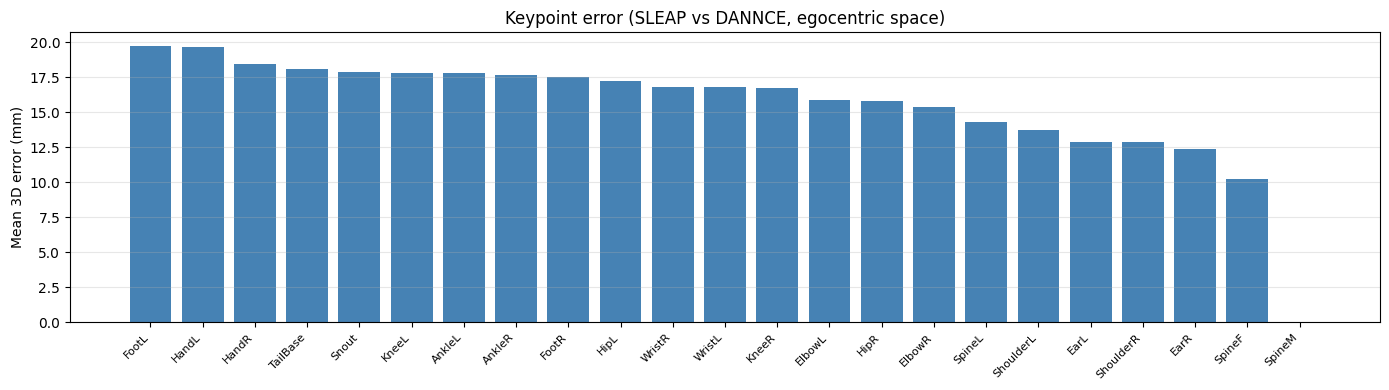

In [61]:
# ── Rank keypoints by SLEAP-DANNCE 3D distance ────────────────────────────────
sleap_fl_8 = sleap_3d_raw.copy(); sleap_fl_8[:, :, 2] = -sleap_fl_8[:, :, 2]
sleap_rot_8,  _, _ = normalize_skeleton_batch(sleap_fl_8)
dannce_rot_8, _, _ = normalize_skeleton_batch(dannce_3d_raw)

kp_diffs = np.linalg.norm(sleap_rot_8 - dannce_rot_8, axis=2)   # (n, 23)
kp_mean_err = np.nanmean(kp_diffs, axis=0)                       # (23,)

order = np.argsort(kp_mean_err)[::-1]
print('Keypoints ranked by SLEAP-DANNCE mean error (worst first):')
for rank, ki in enumerate(order):
    print(f'  {rank+1:>2d}. {NODES[ki]:<20s} mean_err={kp_mean_err[ki]:.2f}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(np.arange(N_KEYPOINTS), kp_mean_err[order], color='steelblue')
ax.set_xticks(np.arange(N_KEYPOINTS))
ax.set_xticklabels([NODES[i] for i in order], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean 3D error (mm)'); ax.set_title('Keypoint error (SLEAP vs DANNCE, egocentric space)')
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

Keeping 18/23 keypoints
Excluded: ['FootL', 'HandL', 'HandR', 'TailBase', 'Snout']

Per-PC MSE (subset):   PC1=103.1  PC2=2327.8
Per-PC MSE (baseline): PC1=306.6  PC2=604.2

  8 — Keypoint subset (exclude 5 worst)
  SLEAP matches :   44  |  DANNCE matches :   49
  Both          :   26  |  SLEAP-only     :   18  |  DANNCE-only :   23
  Alignment     :  38.8%  (26/67)
  PC MSE        : PC1=103.1  PC2=2327.8


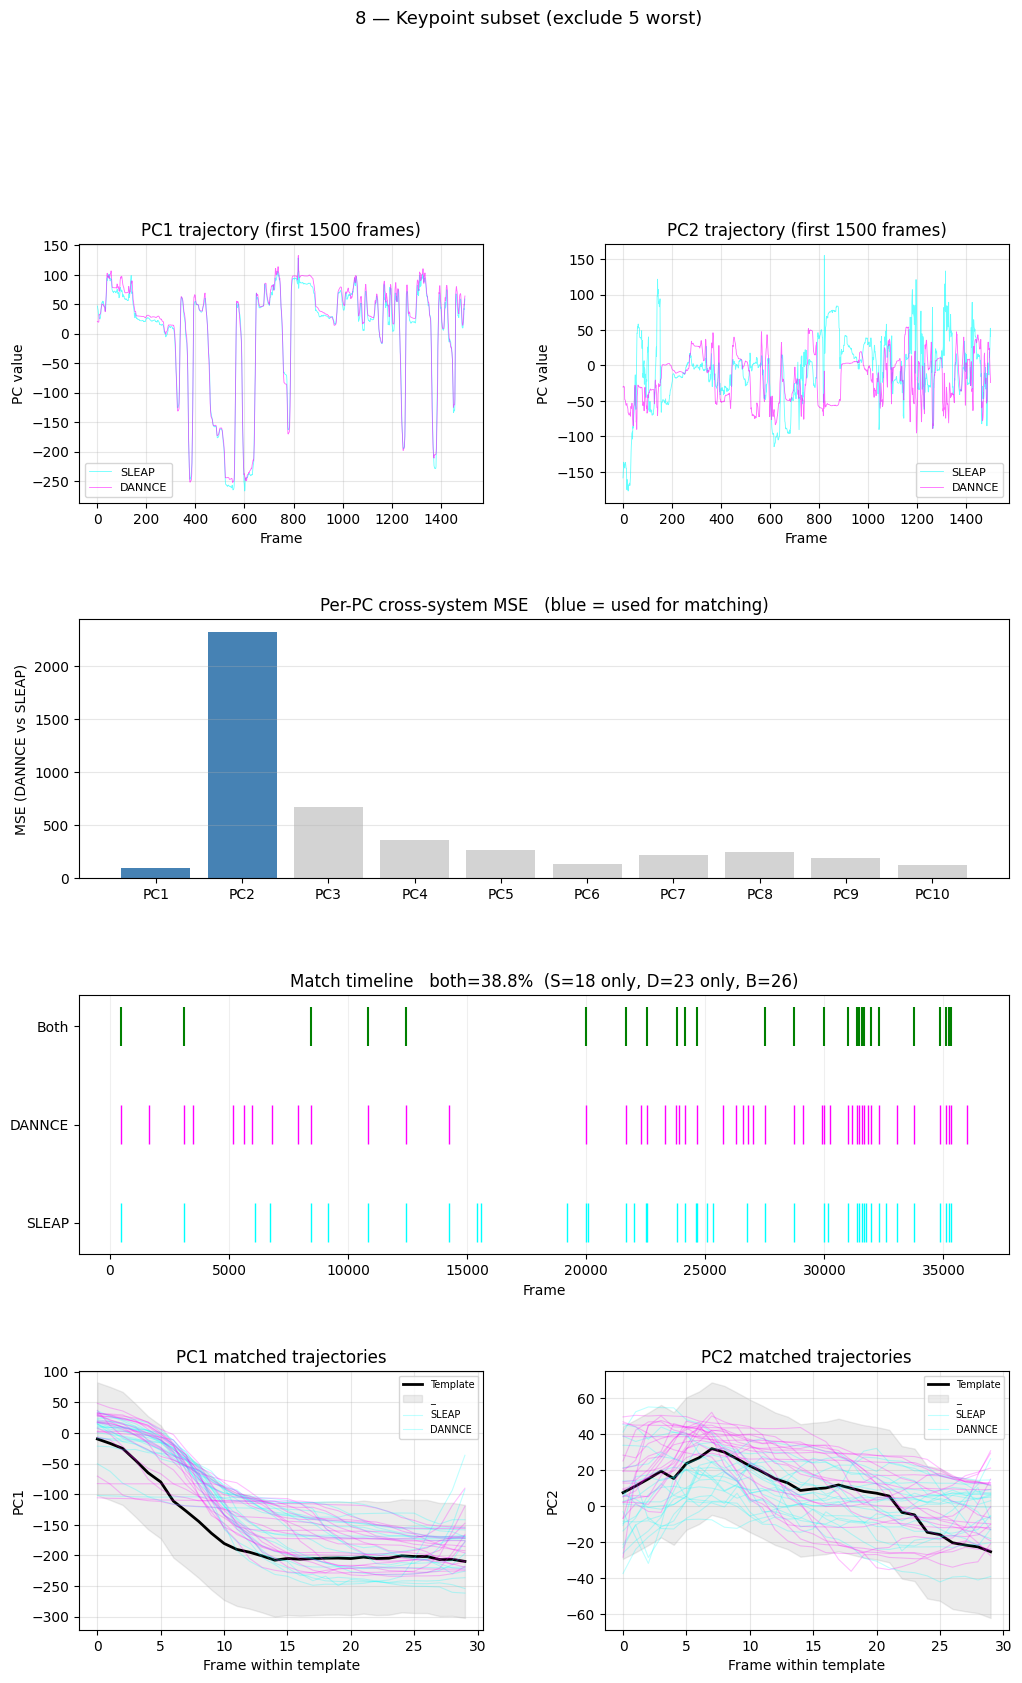

In [62]:
# ── Choose how many to exclude ────────────────────────────────────────────────
N_EXCLUDE = 5   # <── adjust: exclude the N_EXCLUDE highest-error keypoints

exclude_kps = set(order[:N_EXCLUDE].tolist())
keep_kps    = [i for i in range(N_KEYPOINTS) if i not in exclude_kps]
print(f'Keeping {len(keep_kps)}/{N_KEYPOINTS} keypoints')
print(f'Excluded: {[NODES[i] for i in order[:N_EXCLUDE]]}')

# ── Build feature vectors from subset ─────────────────────────────────────────
flat_sleap_8  = sleap_rot_8[:, keep_kps, :].reshape(sleap_rot_8.shape[0],  -1)
flat_dannce_8 = dannce_rot_8[:, keep_kps, :].reshape(dannce_rot_8.shape[0], -1)

feat_pooled_8 = np.concatenate([flat_sleap_8, flat_dannce_8], axis=0)
pw8_weights, pw8_means, pw8_stds, _ = fit_pca_on_features(feat_pooled_8, N_PCA_DIST)

sleap_pcs_8  = (flat_sleap_8  - pw8_means) @ pw8_weights.T
dannce_pcs_8 = (flat_dannce_8 - pw8_means) @ pw8_weights.T

pc_mse_8 = np.mean((dannce_pcs_8 - sleap_pcs_8)**2, axis=0)
print('\nPer-PC MSE (subset):  ', '  '.join([f'PC{i+1}={v:.1f}' for i, v in enumerate(pc_mse_8[:N_COMPONENTS])]))
print('Per-PC MSE (baseline):', '  '.join([f'PC{i+1}={v:.1f}' for i, v in enumerate(ALL_RESULTS['0_Baseline']['pc_mse'][:N_COMPONENTS])]))

# ── Extract template ──────────────────────────────────────────────────────────
orig_sleap_8 = load_sleap_dannce_keys(temp_rat, temp_session)['sleap_keys_3D']
orig_sleap_8 = median_filter(orig_sleap_8, size=(SLEAP_MEDFILT, 1, 1))
start_8 = temp_frame_idx + 1
end_8   = temp_frame_idx + template_length + 1
win_8 = orig_sleap_8[start_8:end_8].copy()
win_8[:, :, 2] = -win_8[:, :, 2]
if len(win_8) < template_length:
    win_8 = np.concatenate([win_8, win_8[-1:].repeat(template_length - len(win_8), axis=0)])
win_8_rot, _, _ = normalize_skeleton_batch(win_8)
flat_win_8 = win_8_rot[:, keep_kps, :].reshape(template_length, -1)
template_pcs_8 = ((flat_win_8 - pw8_means) @ pw8_weights.T)[:, :N_COMPONENTS]

bounds_8 = np.ones_like(template_pcs_8) * bounds_scalar * pw8_stds[:N_COMPONENTS]

sm_8, dm_8 = run_matching(sleap_pcs_8, dannce_pcs_8, template_pcs_8, bounds_8)

ALL_RESULTS['8_Keypoint_subset'] = comparison_report(
    f'8 — Keypoint subset (exclude {N_EXCLUDE} worst)', sleap_pcs_8, dannce_pcs_8, sm_8, dm_8,
    template_pcs_8, bounds_8)

---
# Section 9 — Combined best approaches

Stack whichever individual approaches improved alignment the most.  
Default combination: **DANNCE template + Procrustes alignment + PC-scaled bounds**.  
Change `USE_*` flags to test different combinations.

9 — Combined: Procrustes + DANNCEtemplate + CalBounds(q=95%)

  9 — Combined: Procrustes + DANNCEtemplate + CalBounds(q=95%)
  SLEAP matches : 1097  |  DANNCE matches :  240
  Both          :   67  |  SLEAP-only     : 1030  |  DANNCE-only :  173
  Alignment     :   5.3%  (67/1270)
  PC MSE        : PC1=14527.9  PC2=1439.5


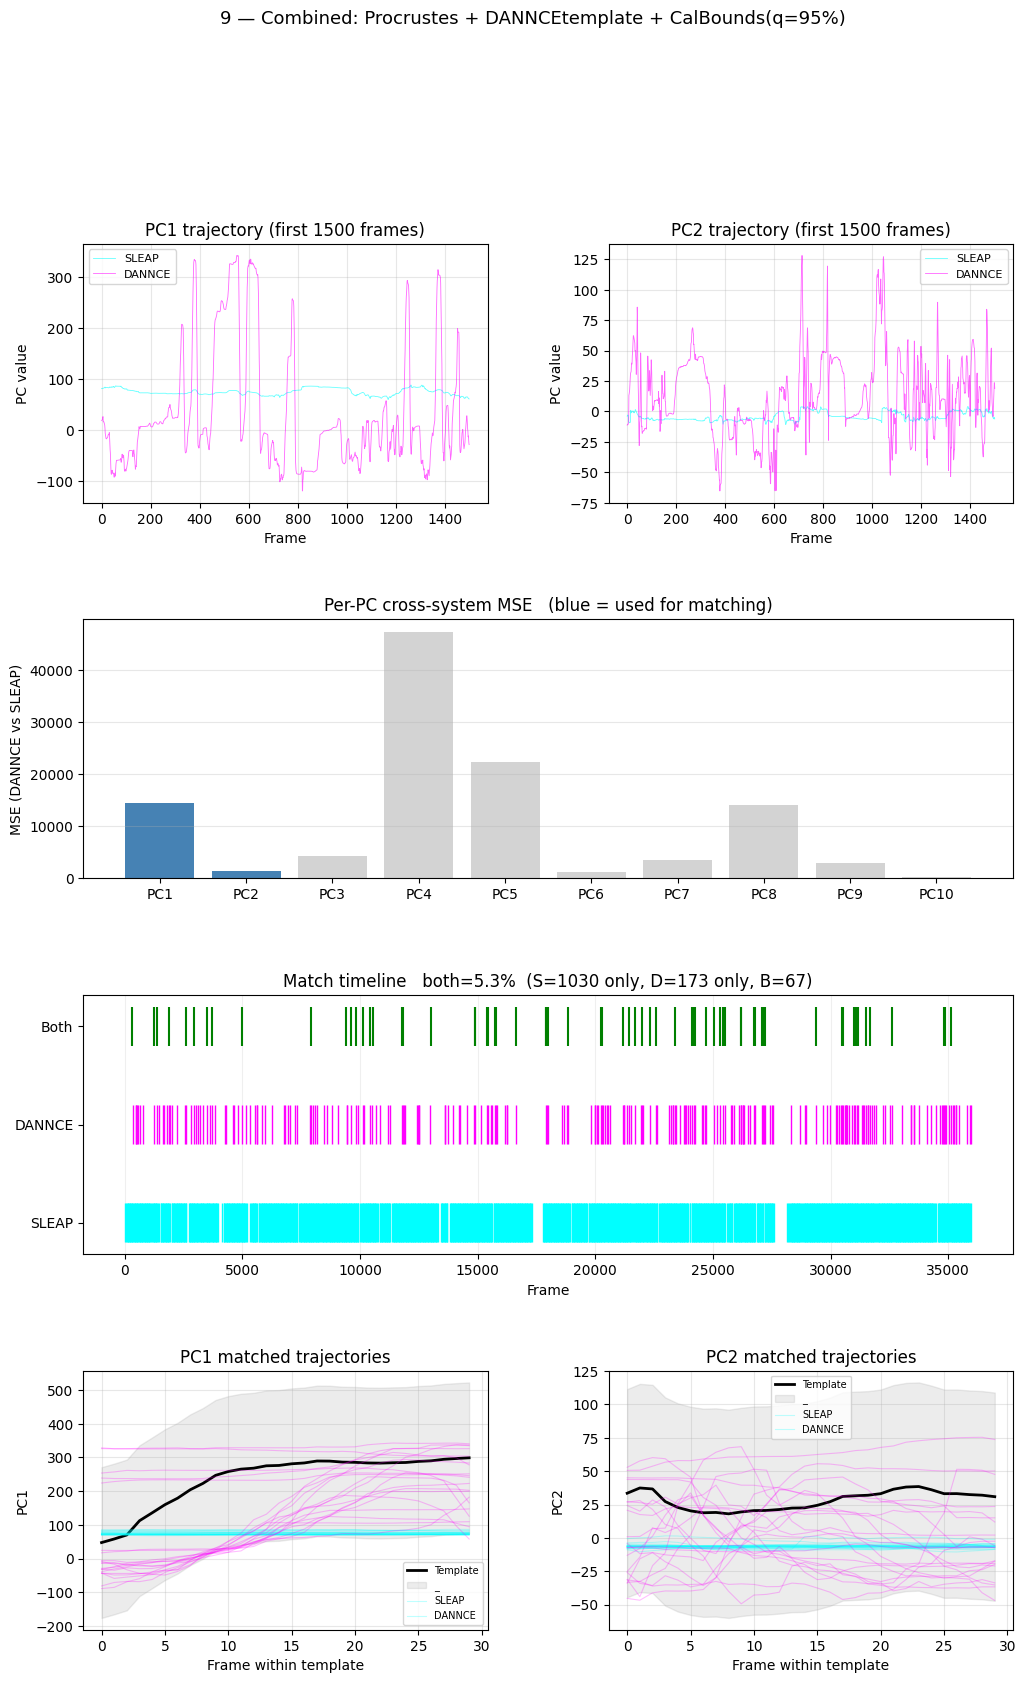

In [63]:
# ── Combination flags — set True to include each component ────────────────────
USE_DANNCE_TEMPLATE    = True    # Section 1
USE_PROCRUSTES         = True    # Section 4
USE_JOINT_MEANS        = False   # Section 3 (mutually exclusive with Procrustes if both True, order matters)
USE_PAIRWISE_DIST      = False   # Section 5 (changes feature space; not combinable with USE_JOINT_MEANS)
USE_CALIBRATED_BOUNDS  = True    # Section 6
USE_PC_OFFSET          = False   # Section 7 (offline only)

label_parts = []

# ── Step 1: choose feature space ──────────────────────────────────────────────
if USE_PAIRWISE_DIST:
    # Pairwise distance feature space (from Section 5)
    # Apply Procrustes first if requested (in 3D before computing distances)
    if USE_PROCRUSTES:
        sleap_in = alignment['apply'](sleap_for_align)   # already z-flipped
        sleap_rot_9, _, _ = normalize_skeleton_batch(sleap_in)
        label_parts.append('Procrustes')
    else:
        sleap_fl_9 = sleap_3d_raw.copy(); sleap_fl_9[:, :, 2] = -sleap_fl_9[:, :, 2]
        sleap_rot_9, _, _ = normalize_skeleton_batch(sleap_fl_9)
    dannce_rot_9, _, _ = normalize_skeleton_batch(dannce_3d_raw)

    feat_s9 = pairwise_distances(sleap_rot_9)
    feat_d9 = pairwise_distances(dannce_rot_9)
    feat_pool_9 = np.concatenate([feat_s9, feat_d9], axis=0)
    w9, m9, st9, _ = fit_pca_on_features(feat_pool_9, N_PCA_DIST)
    sleap_pcs_9  = (feat_s9 - m9) @ w9.T
    dannce_pcs_9 = (feat_d9 - m9) @ w9.T
    used_weights, used_means, used_stds = w9, m9, st9
    label_parts.append('PairwiseDist')

    # Template: re-extract in pairwise distance PCA space
    # Reuse orig_sleap_8 (same session, same filter) loaded in Section 8
    start_9 = temp_frame_idx + 1
    end_9   = temp_frame_idx + template_length + 1
    win_9 = orig_sleap_8[start_9:end_9].copy()
    win_9[:, :, 2] = -win_9[:, :, 2]
    if len(win_9) < template_length:
        win_9 = np.concatenate([win_9, win_9[-1:].repeat(template_length - len(win_9), axis=0)])
    if USE_PROCRUSTES:
        win_9 = alignment['apply'](win_9)  # already z-flipped above
    win_9_rot, _, _ = normalize_skeleton_batch(win_9)
    feat_win_9 = pairwise_distances(win_9_rot)
    if USE_DANNCE_TEMPLATE:
        # Use DANNCE origin window in pairwise distance space
        dannce_win_9 = orig_dannce[start_1:end_1].copy()
        if len(dannce_win_9) < template_length:
            dannce_win_9 = np.concatenate([dannce_win_9, dannce_win_9[-1:].repeat(template_length - len(dannce_win_9), axis=0)])
        dannce_win_9_rot, _, _ = normalize_skeleton_batch(dannce_win_9)
        feat_win_9 = pairwise_distances(dannce_win_9_rot)
        label_parts.append('DANNCEtemplate')
    pc_template_9 = ((feat_win_9 - m9) @ w9.T)[:, :N_COMPONENTS]

else:
    # Standard (x,y,z) feature space
    if USE_PROCRUSTES:
        sleap_in_9 = alignment['apply'](sleap_for_align)   # already z-flipped
        sleap_rot_9, _, _ = normalize_skeleton_batch(sleap_in_9)
        label_parts.append('Procrustes')
    else:
        sleap_fl_9 = sleap_3d_raw.copy(); sleap_fl_9[:, :, 2] = -sleap_fl_9[:, :, 2]
        sleap_rot_9, _, _ = normalize_skeleton_batch(sleap_fl_9)
    dannce_rot_9, _, _ = normalize_skeleton_batch(dannce_3d_raw)

    means_9 = feature_means_joint if USE_JOINT_MEANS else feature_means
    if USE_JOINT_MEANS: label_parts.append('JointMeans')

    sleap_pcs_9  = project_to_pcs(sleap_rot_9,  pc_weights, means_9)
    dannce_pcs_9 = project_to_pcs(dannce_rot_9, pc_weights, means_9)
    used_weights, used_means, used_stds = pc_weights, means_9, feature_stds

    # Template
    if USE_DANNCE_TEMPLATE:
        pc_template_9 = dannce_template_pcs[:, :N_COMPONENTS]
        label_parts.append('DANNCEtemplate')
    else:
        pc_template_9 = pc_template_full[:, :N_COMPONENTS]

# ── PC offset correction (offline only) ──────────────────────────────────────
if USE_PC_OFFSET:
    off_9 = sleap_pcs_9[:, :N_COMPONENTS].mean(axis=0) - dannce_pcs_9[:, :N_COMPONENTS].mean(axis=0)
    sc_9  = dannce_pcs_9[:, :N_COMPONENTS].std(axis=0) / (sleap_pcs_9[:, :N_COMPONENTS].std(axis=0) + 1e-8)
    sleap_pcs_9_corr = sleap_pcs_9.copy()
    sleap_pcs_9_corr[:, :N_COMPONENTS] = (sleap_pcs_9[:, :N_COMPONENTS] - off_9) * sc_9
    pc_template_9 = (pc_template_9 - off_9[np.newaxis, :]) * sc_9[np.newaxis, :]
    sleap_pcs_9 = sleap_pcs_9_corr
    label_parts.append('PCoffset')

# ── Bounds ────────────────────────────────────────────────────────────────────
if USE_CALIBRATED_BOUNDS:
    err_abs_9 = np.abs(dannce_pcs_9[:, :N_COMPONENTS] - sleap_pcs_9[:, :N_COMPONENTS])
    pq_9   = np.quantile(err_abs_9, QUANTILE, axis=0)
    cbv_9  = np.maximum(bounds_scalar * used_stds[:N_COMPONENTS], pq_9)
    bounds_9 = np.ones((template_length, N_COMPONENTS)) * cbv_9[np.newaxis, :]
    label_parts.append(f'CalBounds(q={QUANTILE:.0%})')
else:
    bounds_9 = np.ones((template_length, N_COMPONENTS)) * bounds_scalar * used_stds[:N_COMPONENTS][np.newaxis, :]

label_9 = '9 — Combined: ' + ' + '.join(label_parts) if label_parts else '9 — Combined (none selected)'
print(label_9)

sm_9, dm_9 = run_matching(sleap_pcs_9, dannce_pcs_9, pc_template_9, bounds_9)

ALL_RESULTS['9_Combined'] = comparison_report(
    label_9, sleap_pcs_9, dannce_pcs_9, sm_9, dm_9, pc_template_9, bounds_9)

---
# Summary — all approaches

In [64]:
print_summary_table(ALL_RESULTS)


Approach                                  SLEAP  DANNCE  Both  S-only  D-only   %Both  PC MSE (used PCs)
--------------------------------------------------------------------------------------------------------------
0_Baseline                                   26      22    17       9       5   54.8%  307  604
1_DANNCE_template                            33      31    23      10       8   56.1%  307  604
2_PC_scaled_bounds                           33      28    21      12       7   52.5%  307  604
3_Joint_means                                31      27    20      11       7   52.6%  307  604
4_Procrustes                                  0      22     0       0      22    0.0%  14528  1439
5_Pairwise_dist                              45      50    34      11      16   55.7%  3649  1516
6_Calibrated_bounds                          37      35    24      13      11   50.0%  307  604
7_PC_offset                                  26      21    16      10       5   51.6%  213  609
8_Keypoint

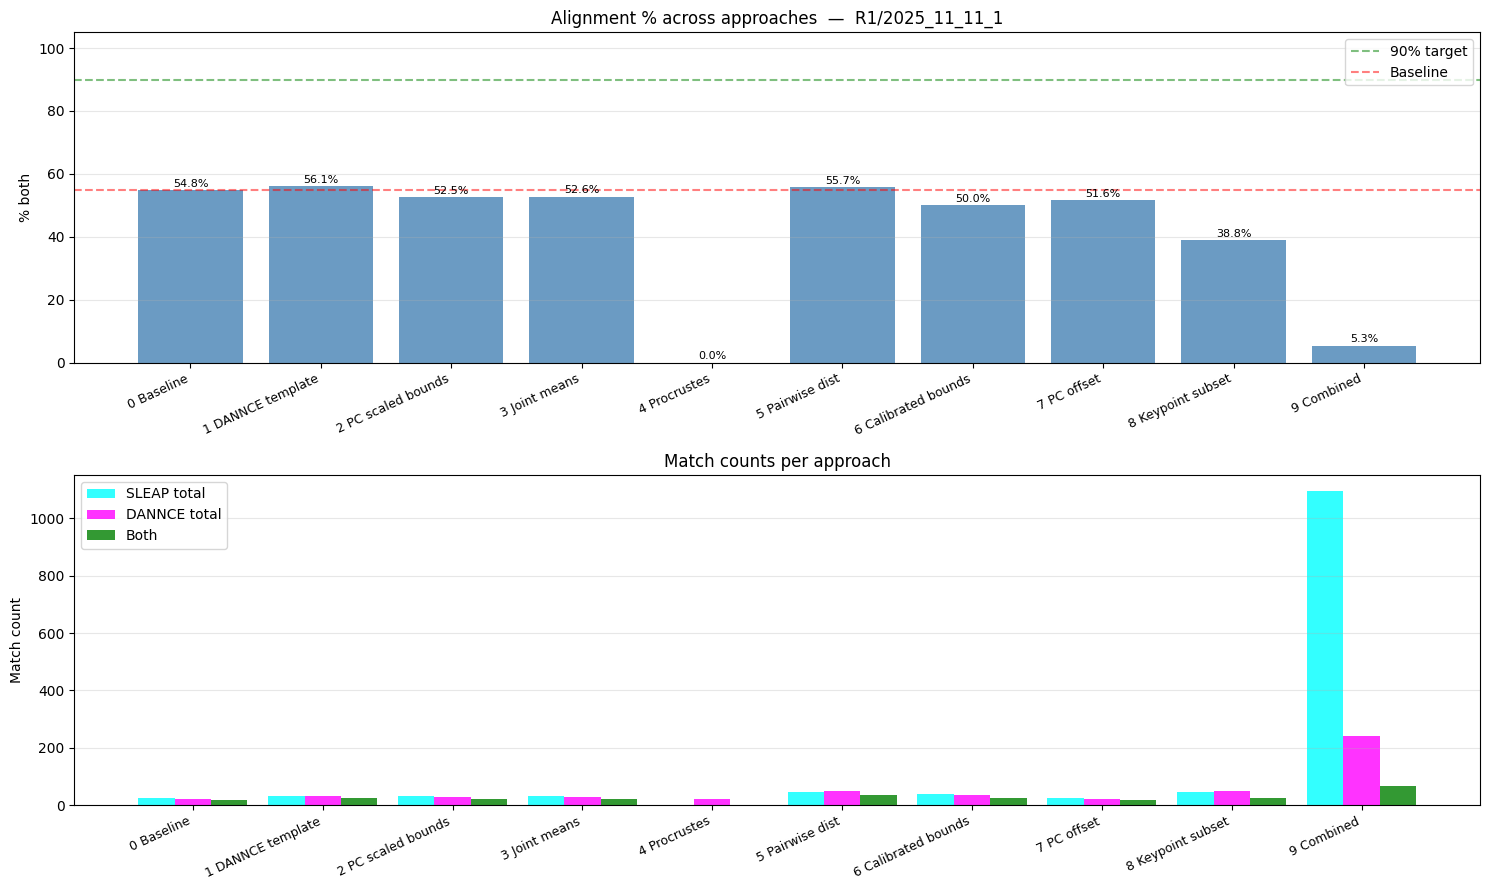

In [65]:
# ── Bar chart: % both across approaches ───────────────────────────────────────
labels_plot = list(ALL_RESULTS.keys())
pct_both_plot = [ALL_RESULTS[k]['pct_both'] for k in labels_plot]
n_both_plot   = [len(ALL_RESULTS[k]['both']) for k in labels_plot]
n_sleap_plot  = [len(ALL_RESULTS[k]['sleap_matches']) for k in labels_plot]
n_dannce_plot = [len(ALL_RESULTS[k]['dannce_matches']) for k in labels_plot]

x = np.arange(len(labels_plot))
fig, axes = plt.subplots(2, 1, figsize=(max(10, len(labels_plot) * 1.5), 9))

# % both
bars = axes[0].bar(x, pct_both_plot, color='steelblue', alpha=0.8)
axes[0].axhline(90, color='green',  ls='--', alpha=0.5, label='90% target')
axes[0].axhline(pct_both_plot[0], color='red', ls='--', alpha=0.5, label='Baseline')
for bar, v in zip(bars, pct_both_plot):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([k.replace('_', ' ') for k in labels_plot], rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('% both'); axes[0].set_ylim(0, 105)
axes[0].set_title(f'Alignment % across approaches  —  {RAT}/{SESSION}')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Match counts
w = 0.28
axes[1].bar(x - w, n_sleap_plot,  width=w, label='SLEAP total', color='cyan',    alpha=0.8)
axes[1].bar(x,      n_dannce_plot, width=w, label='DANNCE total', color='magenta', alpha=0.8)
axes[1].bar(x + w,  n_both_plot,   width=w, label='Both',         color='green',   alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([k.replace('_', ' ') for k in labels_plot], rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('Match count')
axes[1].set_title('Match counts per approach')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

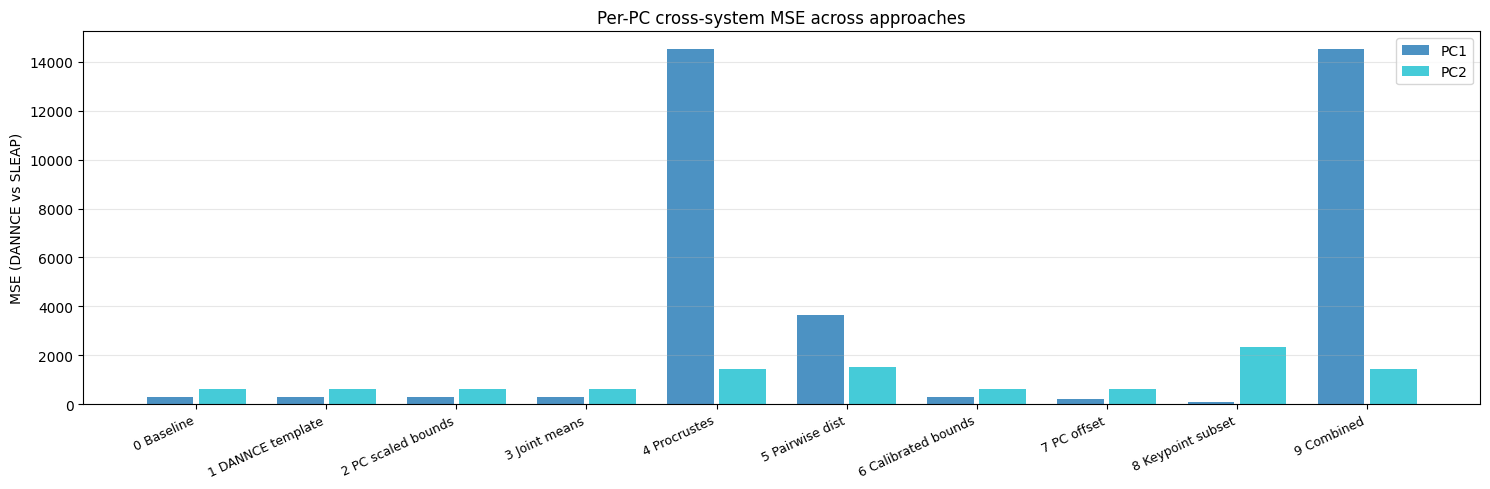

In [66]:
# ── PC MSE comparison across approaches ───────────────────────────────────────
labels_plot = list(ALL_RESULTS.keys())
colors = plt.cm.tab10(np.linspace(0, 1, N_COMPONENTS))

fig, ax = plt.subplots(figsize=(max(10, len(labels_plot) * 1.5), 5))
w = 0.8 / N_COMPONENTS
for pc in range(N_COMPONENTS):
    mse_vals = [ALL_RESULTS[k]['pc_mse'][pc] for k in labels_plot]
    offset   = (pc - (N_COMPONENTS - 1) / 2) * w
    ax.bar(np.arange(len(labels_plot)) + offset, mse_vals,
           width=w * 0.9, label=f'PC{pc+1}', color=colors[pc], alpha=0.8)

ax.set_xticks(np.arange(len(labels_plot)))
ax.set_xticklabels([k.replace('_', ' ') for k in labels_plot], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('MSE (DANNCE vs SLEAP)')
ax.set_title('Per-PC cross-system MSE across approaches')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

---
# Multi-session analysis

Run the best approach across all sessions.  
Set `RUN_MULTI_SESSION = True` in the Configuration cell and re-run.

Will process 73 sessions for R1


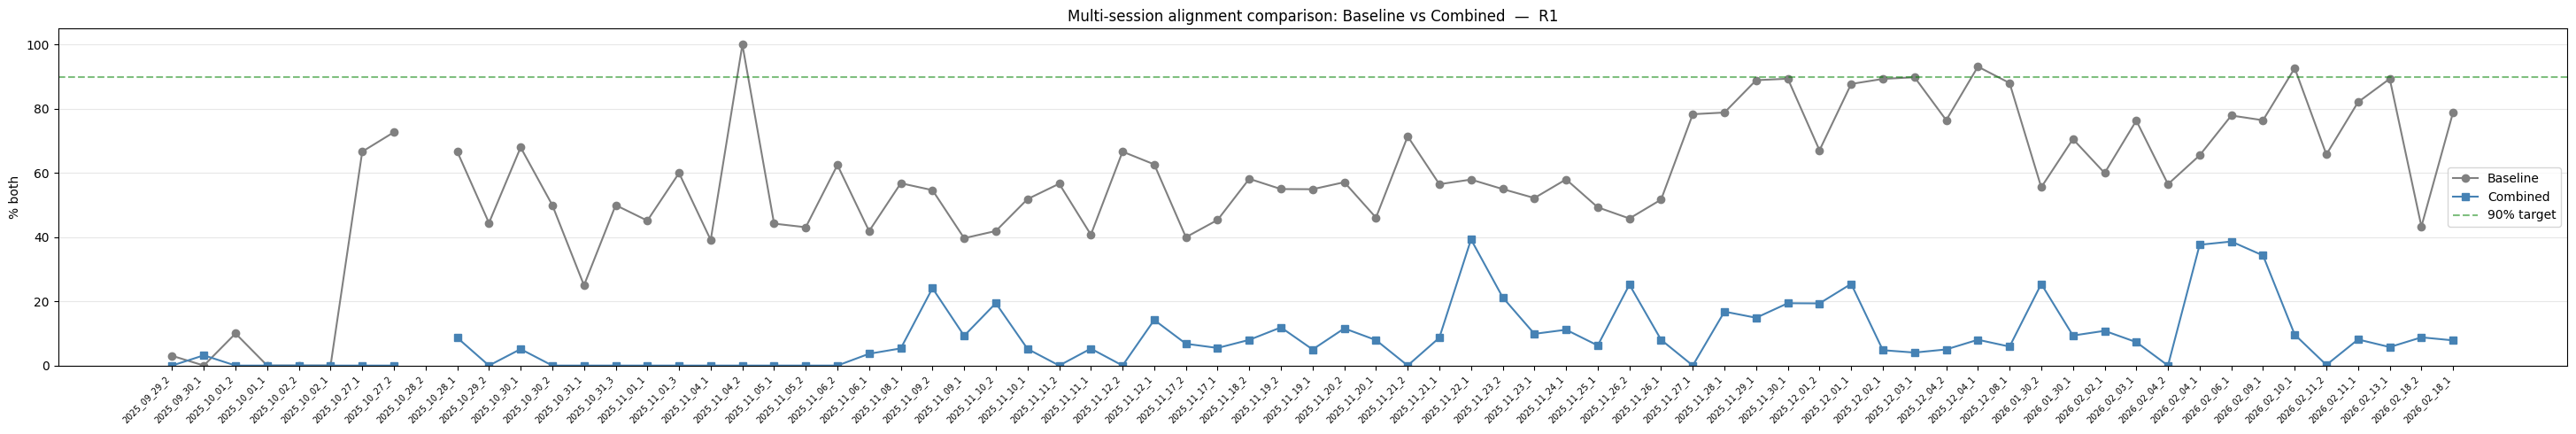


Mean %both — Baseline: 57.5%   Combined: 8.6%


In [81]:
RUN_MULTI_SESSION = True

if not RUN_MULTI_SESSION:
    print('RUN_MULTI_SESSION=False — skipping. Set to True in config cell to run.')
else:
    df = load_session_df()
    rat_sessions = df[df['rat'] == RAT]['session'].tolist()
    session_list = [(RAT, s) for s in rat_sessions]
    print(f'Will process {len(session_list)} sessions for {RAT}')

    def get_session_match_stats_v2(rat, session, approach='baseline'):
        """
        Run a single session through the chosen approach.
        approach: 'baseline' | 'dannce_template' | 'calibrated_bounds' | 'combined'
        """
        sl3d, dn3d, aln_idx = load_raw_keypoints(rat, session)
        td = load_template(rat, TEMPLATE_FILE)
        pc_w   = td['pc_weights']
        f_means = td['feature_means']
        f_stds  = td['feature_stds']
        bscal   = float(td['bounds'])
        pct_full = td['template'][:, :N_COMPONENTS]
        T = pct_full.shape[0]

        # ── Preprocess ──
        if approach in ('combined', 'procrustes'):
            sl_fl = sl3d.copy(); sl_fl[:, :, 2] = -sl_fl[:, :, 2]
            aln   = find_sleap_dannce_alignment(sl_fl, dn3d, aln_idx,
                                                n_sample_frames=500, seed=42, try_z_flip=False)
            sl_fl = aln['apply'](sl_fl)
            sl_rot, _, _ = normalize_skeleton_batch(sl_fl)
        else:
            sl_fl = sl3d.copy(); sl_fl[:, :, 2] = -sl_fl[:, :, 2]
            sl_rot, _, _ = normalize_skeleton_batch(sl_fl)

        dn_rot, _, _ = normalize_skeleton_batch(dn3d)
        sl_pcs  = project_to_pcs(sl_rot,  pc_w, f_means)
        dn_pcs  = project_to_pcs(dn_rot,  pc_w, f_means)
        pc_mse  = np.mean((dn_pcs - sl_pcs)**2, axis=0)

        # ── Template ──
        if approach in ('dannce_template', 'combined'):
            template_use = pc_template_1  # pre-computed DANNCE template
        else:
            template_use = pct_full

        # ── Bounds ──
        if approach in ('calibrated_bounds', 'combined'):
            ea = np.abs(dn_pcs[:, :N_COMPONENTS] - sl_pcs[:, :N_COMPONENTS])
            pq = np.quantile(ea, QUANTILE, axis=0)
            cbv = np.maximum(bscal * f_stds[:N_COMPONENTS], pq)
            bounds_use = np.ones((T, N_COMPONENTS)) * cbv[np.newaxis, :]
        else:
            bounds_use = np.ones((T, N_COMPONENTS)) * bscal * f_stds[:N_COMPONENTS]

        sm, dm = run_matching(sl_pcs, dn_pcs, template_use, bounds_use)
        so, do, bo = get_match_overlap(dm, sm)
        return so, do, bo, pc_mse

    # ── Run both baseline and combined across all sessions ──────────────────────
    from visualization import session_to_datetime
    results_baseline = {'session': [], 'sleap_only': [], 'dannce_only': [], 'both': [], 'pc_error': []}
    results_combined = {'session': [], 'sleap_only': [], 'dannce_only': [], 'both': [], 'pc_error': []}

    for rat_s, sess in session_list:
        for approach, storage in [('baseline', results_baseline), ('combined', results_combined)]:
            try:
                so, do, bo, mse = get_session_match_stats_v2(rat_s, sess, approach=approach)
                storage['session'].append(sess)
                storage['sleap_only'].append(so)
                storage['dannce_only'].append(do)
                storage['both'].append(bo)
                storage['pc_error'].append(mse)
            except Exception as e:
                print(f'{sess}/{approach} FAILED: {e}')

    # ── Plot comparison ──────────────────────────────────────────────────────────
    def pct_both_series(results):
        out = []
        for so, do, bo in zip(results['sleap_only'], results['dannce_only'], results['both']):
            n = len(so) + len(do) + len(bo)
            out.append(100.0 * len(bo) / n if n > 0 else np.nan)
        return np.array(out)

    sessions_sorted = results_baseline['session']
    try:
        ord_ = sorted(range(len(sessions_sorted)), key=lambda i: session_to_datetime(sessions_sorted[i]))
    except Exception:
        ord_ = list(range(len(sessions_sorted)))

    ss = [sessions_sorted[i] for i in ord_]
    pb_base = pct_both_series(results_baseline)[ord_]
    pb_comb = pct_both_series(results_combined)[ord_]

    fig, ax = plt.subplots(figsize=(max(12, len(ss) * 0.4), 5))
    x = np.arange(len(ss))
    ax.plot(x, pb_base, 'o-', color='grey',      lw=1.5, label='Baseline')
    ax.plot(x, pb_comb, 's-', color='steelblue', lw=1.5, label='Combined')
    ax.axhline(90, color='green', ls='--', alpha=0.5, label='90% target')
    ax.set_xticks(x)
    ax.set_xticklabels(ss, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('% both'); ax.set_ylim(0, 105)
    ax.set_title(f'Multi-session alignment comparison: Baseline vs Combined  —  {RAT}')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f'\nMean %both — Baseline: {np.nanmean(pb_base):.1f}%   Combined: {np.nanmean(pb_comb):.1f}%')